# Module 11 — Decision Trees
## Structure · Entropy · Gini · Information Gain · Pruning · Evaluation · ROC-AUC
---
> Decision Tree হলো ML-এর সবচেয়ে **interpretable** model।
> এটা বোঝা মানে **Random Forest** ও **XGBoost**-এর foundation বোঝা।
> এই module-এ theory + code + evaluation সবকিছু একসাথে শেখা হবে।

| Section | Topic |
|---|---|
| 11.1 | Introduction — কেন Decision Tree? |
| 11.2 | Tree Structure — Root, Internal, Leaf, Branch |
| 11.3 | Entropy, Gini Index, Information Gain |
| 11.4 | Synthetic Data দিয়ে Tree তৈরি |
| 11.5 | Overfitting ও Pruning |
| 11.6-7 | Accuracy, Precision, Recall, F1, Confusion Matrix |
| 11.8-9 | ROC Curve, AUC, Threshold |
| 11.10 | Conclusion |


---
## Setup — Libraries


In [2]:
# Now we import all libraries needed for this module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_curve, auc, roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

print("All libraries imported!")

All libraries imported!


> 📝 **এই code-এ কী হচ্ছে:** সব দরকারি library import করা হয়েছে। `sklearn.tree`, `sklearn.metrics` — এই module-এর মূল tools।

---
## 11.1 Introduction — কেন Decision Tree শিখব?

### Real-life Analogy (PDF Slide থেকে)
> ডাক্তার রোগী দেখার সময় প্রশ্ন করেন:
> *'বয়স ৩০-এর কম?'* → হ্যাঁ → *'অনেক পিৎজা খাও?'* → হ্যাঁ → **Unfit!**
> *'বয়স ৩০-এর বেশি?'* → *'সকালে exercise করো?'* → হ্যাঁ → **Fit!**
> এই if-else প্রশ্নের chain-ই Decision Tree।

### Decision Tree কেন গুরুত্বপূর্ণ? (PDF থেকে)

| বৈশিষ্ট্য | বিস্তারিত |
|---|---|
| **Simple & Intuitive** | মানুষ যেভাবে সিদ্ধান্ত নেয় সেভাবে কাজ করে |
| **Easy to Visualize** | Flowchart-এর মতো দেখানো যায়, non-technical stakeholder বোঝে |
| **Versatile Data Handling** | Numeric ও categorical দুটোই handle করে |
| **Minimal Preprocessing** | Feature scaling দরকার নেই |
| **Non-linear Patterns** | Complex, non-linear relationship ধরতে পারে |
| **Excellent Baseline** | Quick to train — baseline model হিসেবে perfect |

### Decision Tree কেন শিখব?
```
Decision Tree বুঝলে বুঝতে পারবে:
  Random Forest    -> অনেক Decision Tree একসাথে (Ensemble)
  XGBoost          -> Decision Tree chain করা (Boosting)
  Feature Importance -> কোন feature important সেটা tree থেকে বোঝা
```

### Linear Regression vs Decision Tree

| | Linear/Logistic Regression | Decision Tree |
|---|---|---|
| কীভাবে সিদ্ধান্ত | Mathematical equation (wx+b) | If-else rules |
| Non-linear pattern | ধরতে পারে না | পারে |
| Feature Scaling | দরকার | **দরকার নেই** |
| Interpretability | Medium | **Very High** |
| Overfitting ঝুঁকি | কম | বেশি (Pruning দরকার) |

### 🎯 Interview Topics
- Decision Tree scale-invariant কেন? → Split করার সময় শুধু order দেখে, actual value নয়
- Decision Tree কি regression-এ ব্যবহার হয়? → হ্যাঁ, `DecisionTreeRegressor` আছে
- সবচেয়ে বড় weakness? → Overfitting — training data memorize করে
- High variance মানে কী? → Training data একটু বদলালে সম্পূর্ণ আলাদা tree হয়


---
## 11.2 Decision Tree Structure

**Tree** হলো পুরো structure — একটার পর একটা **প্রশ্ন করতে করতে** সিদ্ধান্তে পৌঁছায়।

**Node** হলো সেই প্রতিটি **প্রশ্নের জায়গা**।
- **Root Node** → প্রথম প্রশ্ন (সবচেয়ে গুরুত্বপূর্ণ)
- **Internal Node** → মাঝের প্রশ্নগুলো
- **Leaf Node** → শেষ উত্তর (আর প্রশ্ন নেই)


### Tree-এর Anatomy (PDF Slide থেকে)
```
            [Root Node]         <- সবচেয়ে উপরে, সবচেয়ে important split
           Age < 30?
          /         \
        Yes           No
         |             |
  [Internal Node]  [Internal Node]
  Pizza খাও?      Morning Exercise?
    /    \            /      \
  Yes    No         Yes      No
   |      |          |        |
[Leaf] [Leaf]    [Leaf]    [Leaf]
Unfit   Fit       Fit      Unfit   <- Leaf Node-এ final prediction
```

### চারটি Component (PDF Slide থেকে)

| Component | মানে | Role |
|---|---|---|
| **Root Node** | সবচেয়ে উপরের node | সবচেয়ে important split — সব data এখান দিয়ে যায় |
| **Internal Node** | মাঝখানের node | আরো প্রশ্ন করে data আরো ভাগ করে |
| **Branch** | দুটো node-এর connection | condition-এর answer (Yes/No, True/False) |
| **Leaf Node** | শেষ node | Final prediction — majority class বা mean value |

### Tree কীভাবে Split বেছে নেয়?
> প্রতিটি node-এ সেই feature ও threshold বেছে নেওয়া হয় যেটায়
> split করলে দুটো group **সবচেয়ে pure** হয়।

## ✂️ Split ও Threshold
**Split** মানে data-কে **দুই ভাগে ভাগ করা**।
**Threshold** হলো সেই **কাটার রেখা**।
> উদাহরণ: "Age > 30?" — এখানে **30 হলো threshold**। এর উপরে এক দল, নিচে আরেক দল।


**Pure group** = একটি class-ই বেশি আছে → confident prediction সম্ভব
**Impure group** = 50-50 mixed → কোনো confident prediction নয়

### Impurity-র তিনটি Level (PDF থেকে)
| Group | Content | Purity |
|---|---|---|
| Group A | 10 Yes, 0 No | **Perfect Pure** — Entropy=0, Gini=0 |
| Group B | 5 Yes, 5 No | **Maximum Impure** — Entropy=1, Gini=0.5 |
| Group C | 8 Yes, 2 No | **Moderate Pure** — between A and B |


## 🎯 Pure vs Impure Group

| Group | অর্থ | উদাহরণ |
|---|---|---|
| **Perfect Pure** | সবাই একই class | ১০ জনের মধ্যে ১০ জনই "হ্যাঁ" |
| **Moderate Pure** | বেশিরভাগ একই class | ১০ জনের মধ্যে ৭ জন "হ্যাঁ" |
| **Maximum Impure** | ঠিক অর্ধেক অর্ধেক | ১০ জনের মধ্যে ৫ জন "হ্যাঁ", ৫ জন "না" |

> 💡 Tree সবসময় **সবচেয়ে pure group** তৈরি করে এমন split খোঁজে।

## 🚨 Overfitting

Tree যদি **অনেক বেশি গভীর** হয় — সে training data **মুখস্থ** করে ফেলে।
নতুন data দিলে **ভুল করে** — কারণ সে শুধু পুরনো pattern চেনে।
> ⚠️ এটাই **Overfitting** — Training-এ 100%, Test-এ খারাপ।
**সমাধান:** Tree-র depth **সীমিত** রাখো।

### 🎯 Interview Topics
- Root node কোন feature পায়? → সবচেয়ে বেশি Information Gain দেওয়া feature
- Leaf node-এ কী থাকে? → Majority class (classification) বা mean (regression)
- Depth বাড়ালে? → Model complex হয়, overfitting ঝুঁকি বাড়ে
- Tree-এর prediction path trace করো → Root থেকে leaf পর্যন্ত যে branch follow করে


In [3]:
# Now we create the cricket dataset from the PDF slide
# Weather (Sunny/Rainy) and Windy (0/1) -> Play? (1/0)

cricket_data = {
    "Weather": ["Sunny", "Rainy", "Sunny", "Sunny", "Rainy", "Rainy", "Sunny", "Rainy"],
    "Windy":   [0,       1,       0,       1,       0,       1,       0,       1],
    "Play":    [1,       0,       1,       1,       0,       0,       1,       0]
}

cricket_dataframe = pd.DataFrame(cricket_data)
print("Cricket Dataset (from PDF slide):")
print(cricket_dataframe)
print()

print("The Decision Rule:")
print("  If Weather = Sunny -> Play Cricket (1)")
print("  If Weather = Rainy -> Don't Play (0)")

Cricket Dataset (from PDF slide):
  Weather  Windy  Play
0   Sunny      0     1
1   Rainy      1     0
2   Sunny      0     1
3   Sunny      1     1
4   Rainy      0     0
5   Rainy      1     0
6   Sunny      0     1
7   Rainy      1     0

The Decision Rule:
  If Weather = Sunny -> Play Cricket (1)
  If Weather = Rainy -> Don't Play (0)


> 📝 **এই code-এ কী হচ্ছে:** PDF slide-এর exact cricket dataset তৈরি করা হয়েছে। এই simple dataset দিয়ে decision tree-এর basic concept বোঝানো হবে।

In [4]:
# Now we encode categorical feature and train the tree (module notebook exact code)

cricket_dataframe["Weather_num"] = cricket_dataframe["Weather"].map({"Sunny": 1, "Rainy": 0})
# Explanation: We are converting the text data in 'Weather' into numbers using '.map()'. Machine Learning models cannot understand words like "Sunny", so we change them to 1 and 0.
# বাংলা ব্যাখ্যা: 'Weather' কলামের কথাগুলোকে আমরা '.map()' দিয়ে সংখ্যায় রূপান্তর করছি। মেশিন লার্নিং মডেল "Sunny" বা "Rainy" সরাসরি বোঝে না, তাই সেগুলোকে ১ এবং ০ বানিয়ে দেওয়া হয়েছে।


X_cricket = cricket_dataframe[["Weather_num", "Windy"]]
y_cricket  = cricket_dataframe["Play"]
# Explanation: We are splitting the data into two parts. 'X_cricket' contains the input features (Weather and Wind) used to make a decision, and 'y_cricket' contains the target or result (whether they played or not).
# বাংলা ব্যাখ্যা: আমরা ডেটাকে দুই ভাগে ভাগ করছি। 'X_cricket' এ আছে ইনপুট বা বৈশিষ্ট্য (আবহাওয়া এবং বাতাস) যা দেখে সিদ্ধান্ত নেওয়া হবে, আর 'y_cricket' এ আছে মূল ফলাফল (খেলা হয়েছে কি হয়নি)।


# Train decision tree
cricket_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
cricket_tree.fit(X_cricket, y_cricket)
# Explanation: First, we create the model 'DecisionTreeClassifier' with a 'max_depth' of 3 (meaning the tree can only have 3 levels). Then, we use '.fit()' to let the model learn from our 'X' and 'y' data.
# বাংলা ব্যাখ্যা: প্রথমে আমরা 'DecisionTreeClassifier' মডেলটি তৈরি করছি যেখানে 'max_depth' দেওয়া হয়েছে ৩ (তারমানে গাছটি ৩ লেভেলের বেশি বড় হবে না)। এরপর '.fit()' ব্যবহার করে মডেলটিকে আমাদের ডেটা থেকে শেখানো (Train করা) হচ্ছে।


print("Tree trained!")
print()
print("Tree Rules (text format):")
print(export_text(cricket_tree, feature_names=["Weather_num", "Windy"]))
# Explanation: We are using 'export_text' to print out the internal logic or "rules" the tree learned. This shows exactly how the model makes decisions based on 'Weather_num' and 'Windy'.
# বাংলা ব্যাখ্যা: গাছটি ভেতর ভেতর কী কী নিয়ম বা "Rules" শিখলো তা আমরা 'export_text' দিয়ে প্রিন্ট করছি। এর ফলে আমরা দেখতে পাবো ঠিক কোন কোন শর্তের ওপর ভিত্তি করে মডেলটি সিদ্ধান্ত নিচ্ছে।

Tree trained!

Tree Rules (text format):
|--- Weather_num <= 0.50
|   |--- class: 0
|--- Weather_num >  0.50
|   |--- class: 1



> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact code। `map({'Sunny':1,'Rainy':0})` categorical-কে numeric-এ convert করে। `export_text()` tree-এর if-else rules text হিসেবে দেখায়।

`max_depth` ফিচারের সংখ্যার সাথে সরাসরি সম্পর্কিত নয়। ৩টি ফিচার থাকলে যে `max_depth` ৩ দিতে হবে, এমন কোনো নিয়ম নেই।

নিচে সহজভাবে বুঝিয়ে বলছি এটি কীভাবে কাজ করে এবং কীভাবে সিলেক্ট করবে:

### ১. `max_depth` আসলে কী?
এটি হলো গাছের **"লম্বা"** হওয়ার সীমা। একটি বীজের থেকে অঙ্কুর গজানোর পর সেটি কত তলা পর্যন্ত ডালপালা মেলতে পারবে, এটি মূলত সেটিই ঠিক করে দেয়।
* `max_depth=3` মানে হলো গাছটি সর্বোচ্চ ৩ বার প্রশ্ন করে নিচে নামতে পারবে।

### ২. এটি সিলেক্ট করার নিয়ম (কিভাবে বুঝবে কত দিবে?)

এটি মূলত নির্ভর করে তোমার ডেটার **Complexity** বা জটিলতার ওপর। এটি সিলেক্ট করার সময় দুটি জিনিস মাথায় রাখতে হয়:
* **খুব ছোট দিলে (Underfitting):** যদি তোমার ডেটা অনেক বড় হয় কিন্তু তুমি `max_depth=2` দাও, তবে গাছটি সব তথ্য শেখার আগেই থেমে যাবে। এতে মডেলের একুরেসি কমে যাবে।
* **খুব বড় দিলে (Overfitting):** যদি তুমি `max_depth` অনেক বেশি দাও (যেমন ১০০), তবে গাছটি ডেটার ভেতরকার অপ্রয়োজনীয় খুঁটিনাটি (Noise) মুখস্থ করে ফেলবে। এতে সে তোমার ট্রেইনিং ডেটায় ১০০% রেজাল্ট দিলেও নতুন ডেটা দিলে ফেইল করবে।

### ৩. তাহলে সঠিক সংখ্যাটি কীভাবে পাবে?

বাস্তবে এটি সিলেক্ট করার জন্য নিচের পদ্ধতিগুলো ব্যবহার করা হয়:
* **Trial and Error:** প্রথমে ছোট সংখ্যা (যেমন ৩ বা ৫) দিয়ে শুরু করে দেখা হয় রেজাল্ট কেমন আসছে।
* **Cross-Validation:** বিভিন্ন ডেপথ (৩, ৫, ৭, ১০) দিয়ে টেস্ট করে দেখা হয় কোনটিতে সবথেকে ভালো রেজাল্ট পাওয়া যাচ্ছে।
* **Default:** অনেক সময় আমরা এটি ফাঁকা রাখি, তখন গাছটি যতক্ষণ না পর্যন্ত ডেটা পুরোপুরি "Pure" হচ্ছে ততক্ষণ পর্যন্ত বাড়তে থাকে। তবে বড় ডেটাসেটে এটি রিস্কি।

### ৪. ফিচারের সাথে কি কোনো সম্পর্ক আছে?
সরাসরি সম্পর্ক না থাকলেও একটি মজার বিষয় আছে। তোমার যদি মাত্র ২টি ফিচার থাকে (যেমন: আবহাওয়া আর বাতাস), আর তুমি `max_depth=10` দিয়ে দাও, তবে গাছটি একই ফিচার বারবার ব্যবহার করে ভাগ করতে থাকবে (যেমন: বাতাসের গতি কি ১০? তারপর আবার জিজ্ঞেস করবে বাতাসের গতি কি ১২?)। এতে মডেলটি অনেক বেশি জটিল হয়ে যায় যা সাধারণত ভালো নয়।

**সারকথা:** তোমার ডেটা যদি খুব সিম্পল হয়, তবে **৩ থেকে ৫** এর মধ্যে রাখা ভালো। আর ডেটা যদি অনেক বেশি বড় এবং জটিল হয়, তখন বড় সংখ্যা ট্রাই করতে পারো।

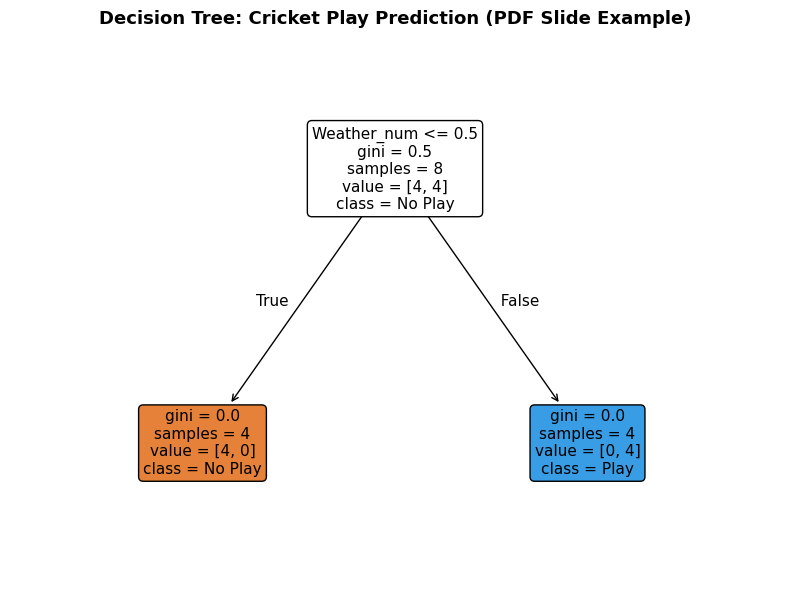

In [5]:
# Now we visualize the decision tree diagram (module notebook exact code)

plt.figure(figsize=(8, 6))
# Explanation: We are setting the size of the drawing area. 'figsize=(8, 6)' means the plot will be 8 inches wide and 6 inches tall, so the tree diagram looks clear and not squeezed.
# বাংলা ব্যাখ্যা: আমরা ছবি বা ডায়াগ্রামটির সাইজ ঠিক করছি। 'figsize=(8, 6)' দিয়ে বোঝানো হয়েছে ছবিটি চওড়ায় ৮ ইঞ্চি এবং লম্বায় ৬ ইঞ্চি হবে, যাতে গাছের ডায়াগ্রামটি পরিষ্কার দেখা যায়।


plot_tree(
    cricket_tree,
    feature_names=["Weather_num", "Windy"],
    class_names=["No Play", "Play"],
    filled=True,
    rounded=True,
    fontsize=11
)
# Explanation: This is the main command to draw the tree. We give it our trained model 'cricket_tree'. 'feature_names' labels the branches, 'class_names' labels the final results, 'filled=True' adds colors to the boxes, and 'rounded=True' makes the corners of the boxes smooth.
# বাংলা ব্যাখ্যা: এটিই গাছটি আঁকার আসল কমান্ড। আমরা আমাদের তৈরি করা 'cricket_tree' মডেলটি এখানে দিচ্ছি। 'feature_names' দিয়ে ডালপালার নাম এবং 'class_names' দিয়ে শেষ ফলাফলগুলোর নাম লেবেল করা হচ্ছে। 'filled=True' দিলে বক্সগুলোতে রঙ হবে এবং 'rounded=True' দিলে বক্সের কোণাগুলো গোল হবে।


plt.title("Decision Tree: Cricket Play Prediction (PDF Slide Example)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: We are adding a bold title to the top of the chart using 'plt.title'. 'plt.tight_layout()' automatically adjusts the spacing so nothing gets cut off, and 'plt.show()' finally displays the window with our complete diagram.
# বাংলা ব্যাখ্যা: 'plt.title' ব্যবহার করে আমরা চার্টের উপরে একটি বোল্ড শিরোনাম দিচ্ছি। 'plt.tight_layout()' চার্টের চারপাশের জায়গাগুলো নিজে থেকেই ঠিক করে নেয় যাতে কোনো কিছু কেটে না যায়, আর 'plt.show()' শেষ পর্যন্ত আমাদের পুরো ডায়াগ্রামটি স্ক্রিনে দেখায়।

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact `plot_tree()` code। `filled=True` দিলে class অনুযায়ী রঙ হয়। Orange = Play (1), Blue = No Play (0)। গাঢ় রঙ = বেশি pure node।

> ### এই chart কীভাবে observe করব

এখন ডায়াগ্রামের প্রতিটি শব্দের সহজ মানে বুঝে নিই:

### ১. Samples (নমুনা)
ঐ বক্সে বা নোডে কতগুলো ডেটা পয়েন্ট আছে। একদম শুরুতে তোমার কাছে মোট **৮টি** ডেটা ছিল, তাই প্রথম বক্সে `samples = 8` লেখা।

### ২. Value (মান)
এটি মূলত ক্লাসের সংখ্যা দেখায়। শুরুতে `value = [4, 4]` মানে হলো— ৪ জন 'না' (No Play) এবং ৪ জন 'হ্যাঁ' (Play) ক্লাসের মানুষ আছে।

### ৩. Gini (অপরিচ্ছন্নতা)
গিনি হলো "জগাখিচুড়ি" মাপার স্কেল।
* যদি বক্সে লাল-নীল সব মিশে থাকে, তবে **Gini = 0.5** (অপরিচ্ছন্ন)।
* যদি বক্সে শুধু এক ধরণের ডেটা থাকে, তবে **Gini = 0.0** (একেবারে পরিষ্কার বা Pure)।

### ৪. কিভাবে Split (ভাগ) হলো?
মডেল দেখলো তার কাছে দুটি প্রশ্ন আছে: 'আবহাওয়া কেমন?' এবং 'বাতাস আছে কি?'। সে দেখলো যদি সে 'Weather_num <= 0.5' (অর্থাৎ বৃষ্টি হচ্ছে কি না) প্রশ্নটি করে, তবে ডেটা একদম পরিষ্কার দুই ভাগে ভাগ হয়ে যায়।

**বক্সটি কেন বিভক্ত হলো?**
* **বাম দিকে (True):** যাদের আবহাওয়া ০.৫ এর কম (অর্থাৎ বৃষ্টি হচ্ছিল)।
* **ডান দিকে (False):** যাদের আবহাওয়া ০.৫ এর বেশি (অর্থাৎ রোদ ছিল)।

### ৫. Orange Leaf এবং Blue Leaf এর Values কীভাবে আসলো?

**Orange Leaf (বাম দিকের বক্স):**
মডেল দেখলো ঐ ৮ জনের মধ্যে ৪ জন এমন ছিল যাদের সময় বৃষ্টি হচ্ছিল। মজার ব্যাপার হলো, ঐ ৪ জনের কেউই কিন্তু ক্রিকেট খেলেনি!
* তাই এখানে `samples = 4` এবং `value = [4, 0]` (৪ জন 'না', ০ জন 'হ্যাঁ')।
* যেহেতু সবাই এক ক্লাসের (সবাই 'No Play'), তাই এর **Gini = 0.0**। এটি একদম "পরিষ্কার" বা Pure সিদ্ধান্ত।

**Blue Leaf (ডান দিকের বক্স):**
বাকি ৪ জন এমন ছিল যাদের সময় রোদ ছিল। তারা সবাই ক্রিকেট খেলেছে।
* তাই এখানে `samples = 4` এবং `value = [0, 4]` (০ জন 'না', ৪ জন 'হ্যাঁ')।
* এখানেও সবাই এক জাতের, তাই **Gini = 0.0**।

### সারকথা:
গাছটি এমন একটি প্রশ্ন খুঁজে বের করেছে যাতে এক এক দিকে শুধু একই ধরণের রেজাল্ট জমা হয়। যখনই সে রেজাল্ট ১০০% পিওর (**Gini = 0**) পেয়ে গেছে, তখন সে আর নিচে নামেনি বা গাছটিকে আর বড় করেনি।


In [6]:
# Now we make predictions on new examples (module notebook exact code)

# Example 1: Sunny (1), not windy (0)
example_one = pd.DataFrame([[1, 0]], columns=["Weather_num", "Windy"])
prediction_one = cricket_tree.predict(example_one)[0]
print(f"Example One DataFrame:")
print(example_one)
print(f"Sunny, not windy -> Play prediction: {prediction_one} ({'Play' if prediction_one==1 else 'No Play'})")
print()
# Explanation: We are creating a new data point called 'example_one' where the weather is Sunny (1) and it is not windy (0). Then, we use '.predict()' to ask the model for its decision. Finally, we print whether the result is 1 (Play) or 0 (No Play).
# বাংলা ব্যাখ্যা: আমরা 'example_one' নামে একটি নতুন ডেটা তৈরি করছি যেখানে রোদ আছে (1) এবং বাতাস নেই (0)। এরপর আমরা '.predict()' ব্যবহার করে মডেলটিকে জিজ্ঞেস করছি তার সিদ্ধান্ত কী। শেষে আমরা প্রিন্ট করছি ফলাফল কি ১ (খেলবে) নাকি ০ (খেলবে না)।


# Example 2: Rainy (0), windy (1)
example_two = pd.DataFrame([[0, 1]], columns=["Weather_num", "Windy"])
prediction_two = cricket_tree.predict(example_two)[0]
print(f"Example Two DataFrame:")
print(example_two)
print(f"Rainy, windy     -> Play prediction: {prediction_two} ({'Play' if prediction_two==1 else 'No Play'})")
print()
# Explanation: We are testing another scenario: Rainy (0) and Windy (1). The model looks at the 'Weather_num' column first because that's what it learned from the tree. Even though it is windy, the model makes a prediction based on the rules it learned during training.
# বাংলা ব্যাখ্যা: আমরা দ্বিতীয় একটি পরিস্থিতি টেস্ট করছি: বৃষ্টি (0) এবং বাতাস (1)। মডেলটি প্রথমে 'Weather_num' কলামের দিকে তাকাবে কারণ সে গাছ থেকে এটাই শিখেছে। বাতাস থাকলেও মডেলটি ট্রেইনিংয়ের সময় শেখা নিয়ম অনুযায়ী তার সিদ্ধান্ত বা প্রেডিকশন দিচ্ছে।


# Example 3: Rainy (0), not windy (0)
example_three = pd.DataFrame([[0, 0]], columns=["Weather_num", "Windy"])
prediction_three = cricket_tree.predict(example_three)[0]
print(f"Example Three DataFrame:")
print(example_three)
print(f"Rainy, not windy -> Play prediction: {prediction_three} ({'Play' if prediction_three==1 else 'No Play'})")
print()
# Explanation: In this third example, it is Rainy (0) but not windy (0). The model uses '.predict()' again. Based on our earlier tree diagram, we know that if it's Rainy (Weather_num <= 0.5), the model will always predict 0 (No Play), regardless of the wind.
# বাংলা ব্যাখ্যা: এই তৃতীয় উদাহরণে বৃষ্টি আছে (0) কিন্তু বাতাস নেই (0)। মডেলটি আবারও '.predict()' ফাংশনটি ব্যবহার করছে। আমাদের আগের ট্রি ডায়াগ্রাম অনুযায়ী আমরা জানি যে যদি বৃষ্টি থাকে (Weather_num <= 0.5), তবে বাতাস থাকুক বা না থাকুক, মডেলটি সবসময় ০ (খেলবে না) প্রেডিক্ট করবে।

Example One DataFrame:
   Weather_num  Windy
0            1      0
Sunny, not windy -> Play prediction: 1 (Play)

Example Two DataFrame:
   Weather_num  Windy
0            0      1
Rainy, windy     -> Play prediction: 0 (No Play)

Example Three DataFrame:
   Weather_num  Windy
0            0      0
Rainy, not windy -> Play prediction: 0 (No Play)



> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact prediction examples। নতুন data point দিলে tree root থেকে leaf পর্যন্ত path follow করে prediction দেয়।

## 11.3 Entropy, Gini Index, এবং Information Gain

### Entropy — Disorder মাপার tool
> **Entropy** = physics ও information theory থেকে borrowed। একটি group-এ কতটা **disorder** বা **uncertainty** আছে সেটা measure করে। মেশিন লার্নিং বা ডিসিশন ট্রি-তে আমরা এনট্রপি ব্যবহার করি এটা বুঝতে যে আমাদের ডেটা কতটা অগোছালো বা এলোমেলো অবস্থায় আছে।
$$H = -\sum_{i} p_i \log_2(p_i)$$

| Entropy Value | মানে | Group |
|---|---|---|
| **0** | Perfect pure | 10 Yes, 0 No — certainty সর্বোচ্চ |
| **1** | Maximum impure | 5 Yes, 5 No — uncertainty সর্বোচ্চ |
| **0 < H < 1** | Moderate | 8 Yes, 2 No — কিছুটা predictable |

**Intuition:**
- High Entropy = messy, mixed group → tree এটা avoid করতে চায়
- Low Entropy = clean, pure group → tree এটাই তৈরি করতে চায়

### মেশিন লার্নিংয়ে এর কাজ কী?
ডিসিশন ট্রি যখন ডেটা ভাগ (Split) করে, সে সবসময় চায় **Entropy কমাতে**।
* শুরুতে তোমার ডেটা অনেক অগোছালো থাকে (হাই এনট্রপি)।
* গাছটি এমনভাবে প্রশ্ন করে যেন ভাগ হওয়ার পর এক এক দিকে একই ধরণের ডেটা চলে যায় (লো এনট্রপি)।

**সহজ সারকথা:**
* **Entropy বেশি** মানে হলো ডেটা অনেক বেশি মিশ্রিত বা কনফিউজিং।
* **Entropy কম** মানে হলো ডেটা অনেক বেশি গোছানো এবং সেখান থেকে সিদ্ধান্ত নেওয়া সহজ।


### Gini Index — Misclassification মাপার tool
> **Gini Index** = যদি randomly একটি item pick করে randomly একটি label দাও, তাহলে কতটা সম্ভাবনা আছে তুমি ভুল করবে? **Gini Index** (বা Gini Impurity) হলো এনট্রপির মতোই একটি মাপকাঠি, যা দিয়ে বোঝা যায় আমাদের ডেটা কতটা **"অপরিচ্ছন্ন"** বা **"জগাখিচুড়ি"** অবস্থায় আছে। সহজ কথায়, এটি আমাদের বলে যে একটি নির্দিষ্ট গ্রুপের ডেটা কতটা একজাতীয় (Pure)।
$$Gini = 1 - \sum_{i} p_i^2$$

| Gini Value | মানে |
|---|---|
| **0** | Pure group — ভুল করার সম্ভাবনা শূন্য |
| **0.5** | Maximum impure — ভুল করার সম্ভাবনা সর্বোচ্চ |

### ১. গিনি ইনডেক্স-এর মান (The Scale)
গিনি ইনডেক্স-এর মান সাধারণত **০ থেকে ০.৫** এর মধ্যে থাকে।
* **০ (Zero):** এর মানে হলো ডেটা একদম **Pure** বা পরিষ্কার। অর্থাৎ, একটি ঝুড়িতে শুধু এক ধরণের জিনিসই আছে (যেমন: সবগুলোই লাল বল)। এখান থেকে কিছু বেছে নিলে কোনো ভুল হওয়ার সম্ভাবনা নেই।
* **০.৫ (0.5):** এর মানে হলো ডেটা সবচেয়ে বেশি **Impure** বা জগাখিচুড়ি। অর্থাৎ, ঝুড়িতে অর্ধেক লাল আর অর্ধেক নীল বল আছে। এখানে কনফিউশন সবচেয়ে বেশি।

### ২. একটি বাস্তব উদাহরণ
মনে করো তোমার কাছে ১০ জন স্টুডেন্টের ডেটা আছে।
* **পরিস্থিতি A:** ১০ জনের সবাই পাস করেছে। এখানে কোনো ভেজাল নেই, সবাই এক জাতের। তাই এখানকার **Gini Index = 0**।
* **পরিস্থিতি B:** ৫ জন পাস করেছে আর ৫ জন ফেল করেছে। এখানে ডেটা একদম দুই ভাগে বিভক্ত এবং জগাখিচুড়ি অবস্থা। তাই এখানকার **Gini Index = 0.5**।
* **পরিস্থিতি C:** যদি ৩ জন পাস করে এবং ৭ জন ফেল করে, তবে **Gini Index = 0.42**। এখানে ডেটা কিছুটা অগোছালো, তবে পরিস্থিতি B (০.৫) এর তুলনায় কম জগাখিচুড়ি, কারণ এখানে ফেইল করা ছাত্রের সংখ্যা বা পাল্লা কিছুটা ভারী।
* **পরিস্থিতি D:** যদি ১০ জনের সবাই ফেল করে, তবে **Gini Index = 0**। কারণ এখানে কোনো ভিন্নতা নেই, সবাই একই ক্যাটাগরির (সবাই ফেইল)। তাই এটি একটি একদম **Pure** বা পরিষ্কার অবস্থা।

**সহজ টিপস:** মনে রাখবে, যখনই কোনো গ্রুপে সবাই ১০০% একই রকম হয়ে যায় (সবাই পাস বা সবাই ফেল), তখনই **Gini Index** সবসময় **০** হয়। আর যখনই মিক্সড থাকে, তখনই মান ০-এর থেকে বাড়তে থাকে।

### ৩. এনট্রপি বনাম গিনি ইনডেক্স (সহজ পার্থক্য)
তুমি হয়তো ভাবছ এনট্রপি আর গিনি তো একই কাজ করছে, তাহলে পার্থক্য কী?
* **ম্যাথমেটিক্স:** এনট্রপি ব্যবহার করে `Log` (লগারিদম), যা ক্যালকুলেট করতে কম্পিউটারের একটু বেশি সময় লাগে। আর গিনি ইনডেক্স ব্যবহার করে `Square` (বর্গ), যা অনেক দ্রুত ক্যালকুলেট করা যায়।
* **ব্যবহার:** একারণেই বড় ডেটাসেটে ডিসিশন ট্রি ট্রেইন করার সময় **Gini Index** বেশি জনপ্রিয়, কারণ এটি মডেলকে দ্রুত কাজ করতে সাহায্য করে।

### ৪. ডিসিশন ট্রি কীভাবে এটি ব্যবহার করে?
ডিসিশন ট্রি যখন ডেটাকে ভাগ (Split) করে, সে অনেকগুলো প্রশ্ন ট্রাই করে। সে সেই প্রশ্নটিকেই বেছে নেয় যেটির মাধ্যমে ভাগ করলে **Gini Index সবচেয়ে কম** হয় (অর্থাৎ ডেটা সবচেয়ে বেশি পরিষ্কার বা Pure হয়)। গিনি ইনডেক্স যত **কম**, আমাদের সিদ্ধান্ত তত বেশি **সঠিক এবং পরিষ্কার**। ডিসিশন ট্রি-র মূল লক্ষ্যই হলো ডেটাকে ভাগ করে করে গিনি ইনডেক্সকে ০-এর কাছাকাছি নিয়ে আসা।

গিনি ইনডেক্স আর এনট্রপির এই "পরিচ্ছন্নতা" মাপার ধারণাটি কি তোমার কাছে পরিষ্কার হয়েছে?

**Entropy vs Gini:**
- দুটোই same কাজ করে — impurity measure করা
- sklearn default: **Gini** (`criterion='gini'`)
- Entropy দিতে: `criterion='entropy'`
- Practice-এ দুটো result প্রায়ই একই

### Information Gain — Split কতটা ভালো সেটা মাপে
> **Information Gain** = split করার আগে ও পরে impurity-র পার্থক্য। Tree সেই split বেছে নেয় যেটায় Information Gain সবচেয়ে বেশি। **Information Gain (ইনফরমেশন গেইন)** হলো একটি লাভ-ক্ষতির হিসাব। সহজ কথায়, কোনো একটি প্রশ্ন করার আগে ডেটা কতটা অগোছালো ছিল এবং প্রশ্নটি করার পর ডেটা কতটা গোছানো হলো—এই দুইয়ের পার্থক্যকেই বলা হয় ইনফরমেশন গেইন। Decision Tree এই হিসাবটি ব্যবহার করে সিদ্ধান্ত নেয় যে কোন ফিচারটি (Feature) দিয়ে সে ডেটা ভাগ করবে।

$$IG = H_{parent} - \frac{n_{left}}{n} H_{left} - \frac{n_{right}}{n} H_{right}$$

**Simple Example (PDF Slide থেকে):**
```
Parent: 6 Yes, 4 No  -> Gini = 0.48 (impure)
           |
        Split!
       /        \
Left: 5Y, 0N    Right: 1Y, 4N
Gini = 0.00     Gini = 0.32

Information Gain = 0.48 - (5/10)*0.00 - (5/10)*0.32 = 0.32
```
Left child perfectly pure (Gini=0)! এই split excellent।


### ১. মূল আইডিয়া (The Concept)
* **আগের অবস্থা:** ডেটা যখন জগাখিচুড়ি বা অগোছালো থাকে (বেশি এনট্রপি)।
* **পরের অবস্থা:** ডেটা ভাগ করার পর যখন গোছানো হয়ে যায় (কম এনট্রপি)।
* **গেইন (Gain):** অগোছালো অবস্থা যতটুকু কমলো, সেটাই তোমার লাভ বা "Information Gain"।

### ২. একটি বাস্তব উদাহরণ
মনে করো, তুমি ঠিক করবে তুমি "বই পড়বে কি না"। তোমার কাছে ২টি তথ্য আছে: ১. লাইট আছে কি না, ২. ঘরের রঙ কী।

* **ধাপ ১:** শুরুতে তোমার পড়ার সম্ভাবনা ৫০-৫০ (অনেক অগোছালো/High Entropy)।
* **ধাপ ২ (প্রশ্ন ১ - লাইট):** তুমি দেখলে "লাইট আছে" প্রশ্নটি করলে তুমি নিশ্চিত হতে পারছো যে লাইট থাকলে পড়বে, না থাকলে পড়বে না। এখানে ডেটা একদম পরিষ্কার হয়ে গেল। অর্থাৎ, এখানে **Information Gain অনেক বেশি**।
* **ধাপ ৩ (প্রশ্ন ২ - ঘরের রঙ):** তুমি দেখলে ঘরের রঙ নীল হোক বা লাল, তা তোমার পড়ার সিদ্ধান্তে কোনো প্রভাব ফেলছে না। ডেটা আগের মতোই অগোছালো রয়ে গেল। অর্থাৎ, এখানে **Information Gain শূন্য (০)**।


### ৩. ডিসিশন ট্রি কীভাবে এটি ব্যবহার করে?
ডিসিশন ট্রি তার সবকটি ফিচারের (যেমন: Weather, Humidity, Windy) জন্য আলাদা আলাদা করে Information Gain ক্যালকুলেট করে।
> **নিয়ম:** যে ফিচারের মাধ্যমে ভাগ করলে **সবচেয়ে বেশি ইনফরমেশন গেইন** হবে (অর্থাৎ জগাখিচুড়ি অবস্থা সবথেকে বেশি কমবে), গাছটি সেই ফিচারটিকেই তার ডালপালা হিসেবে বেছে নেয়।

### ৪. গাণিতিক সূত্র (সহজভাবে)
$$Information\ Gain = Entropy(Before\ Split) - Entropy(After\ Split)$$

**সারকথা:**
ইনফরমেশন গেইন হলো একটি "ফিল্টার" এর মতো। এটি খুঁজে বের করে কোন প্রশ্নটি করলে আমরা সবথেকে পরিষ্কার উত্তর পাবো। গেইন যত বেশি হবে, ওই ফিচারটি আমাদের সিদ্ধান্তের জন্য তত বেশি গুরুত্বপূর্ণ।















### 🎯 Interview Topics
- Entropy range? → 0 (pure) to 1 (binary, maximum impure) বা log₂(k) for k classes
- Gini range? → 0 (pure) to 0.5 (binary, maximum impure)
- Entropy vs Gini কোনটা ব্যবহার করব? → Practice-এ same result, Gini computationally faster
- Information Gain maximize করা মানে? → সবচেয়ে বেশি uncertainty কমানো
- Greedy algorithm কেন? → প্রতিটি node-এ locally best split নেয়, globally optimal নাও হতে পারে


In [32]:
# Now we compute Entropy and Gini manually to understand the formulas

def compute_entropy(positive_count, negative_count):
    # Compute entropy for a binary group
    total = positive_count + negative_count
    if total == 0:
        return 0
    prob_positive = positive_count / total
    prob_negative = negative_count / total

    # Avoid log(0) -- 0 * log(0) = 0 by convention
    entropy = 0
    if prob_positive > 0:
        entropy -= prob_positive * np.log2(prob_positive)
    if prob_negative > 0:
        entropy -= prob_negative * np.log2(prob_negative)
    return entropy
# Explanation: This function 'compute_entropy' calculates how messy or "mixed" a group is. It finds the probability (percentage) of 'positive_count' and 'negative_count', then uses the 'np.log2' formula to find the entropy value. If a group is perfectly pure, it returns 0.
# বাংলা ব্যাখ্যা: 'compute_entropy' ফাংশনটি দিয়ে আমরা বের করছি একটি গ্রুপ কতটা অগোছালো। এটি 'positive_count' এবং 'negative_count' এর পার্সেন্টেজ বের করে এবং 'np.log2' (লগারিদম) সূত্র ব্যবহার করে এনট্রপির মান ক্যালকুলেট করে। যদি গ্রুপটি একদম পরিষ্কার বা একজাতীয় হয়, তবে এটি ০ রিটার্ন করে।


def compute_gini(positive_count, negative_count):
    # Compute Gini index for a binary group
    total = positive_count + negative_count
    if total == 0:
        return 0
    prob_positive = positive_count / total
    prob_negative = negative_count / total
    return 1 - (prob_positive**2 + prob_negative**2)
# Explanation: This function 'compute_gini' is a faster way to measure impurity. Instead of logs, it uses the square of probabilities ('**2'). It subtracts the squared probabilities from 1 to find the Gini Index.
# বাংলা ব্যাখ্যা: 'compute_gini' ফাংশনটি অপরিচ্ছন্নতা মাপার একটি দ্রুত পদ্ধতি। এটি লগের বদলে প্রোব্যাবিলিটির বর্গ বা 'Square' ব্যবহার করে। ১ থেকে প্রোব্যাবিলিটির বর্গের যোগফল বিয়োগ করলেই আমরা গিনি ইনডেক্স পেয়ে যাই।


# Here we test with the three groups from PDF slide
print("Group Comparisons (from PDF slide):")
print(f"{'Group':<25} {'Content':<15} {'Entropy':>10} {'Gini':>10}")
print("-" * 60)
# Explanation: We are setting up the header for a table using 'print' and string formatting like '<25' (left-align with 25 spaces). This makes the final output look organized like a real report.
# বাংলা ব্যাখ্যা: আমরা টেবিলের হেডার তৈরি করছি যেখানে 'print' এবং '<25' এর মতো ফরম্যাটিং ব্যবহার করা হয়েছে যাতে আউটপুটটি একটি রিপোর্টের মতো সুন্দর এবং গোছানো দেখায়।


groups = [
    ("Group A: Perfect Pure",   10, 0),
    ("Group B: Mostly impure",   8, 2),
    ("Group C: Max Impure",      5, 5),
    ("Group D: Mostly impure",   3, 7),
    ("Group E: Perfect Pure",   0, 10),
]
# Explanation: We created a list called 'groups' containing different scenarios (tuples). Each scenario has a name, the number of 'Yes' (Positive), and the number of 'No' (Negative) cases to test our functions.
# বাংলা ব্যাখ্যা: আমরা 'groups' নামে একটি লিস্ট তৈরি করেছি যেখানে বিভিন্ন পরিস্থিতি রাখা হয়েছে। প্রতিটি পরিস্থিতিতে একটি নাম, 'Yes' এর সংখ্যা এবং 'No' এর সংখ্যা দেওয়া হয়েছে যাতে আমরা আমাদের ফাংশনগুলো পরীক্ষা করতে পারি।


for name, yes_count, no_count in groups:
    entropy = compute_entropy(yes_count, no_count)
    gini    = compute_gini(yes_count, no_count)
    print(f"{name:<25} {yes_count}Y {no_count}N{'':<8} {entropy:>10.4f} {gini:>10.4f}")
# Explanation: We use a 'for' loop to go through each group, calculate their 'entropy' and 'gini' using our custom functions, and print the results side-by-side with 4 decimal places ('.4f').
# বাংলা ব্যাখ্যা: আমরা একটি 'for' লুপ ব্যবহার করে প্রতিটি গ্রুপের ভেতর দিয়ে যাচ্ছি এবং আমাদের তৈরি করা ফাংশন দিয়ে 'entropy' ও 'gini' ক্যালকুলেট করছি। সবশেষে ফলাফলগুলো দশমিকের পর ৪ ঘর পর্যন্ত ('.4f') পাশাপাশি প্রিন্ট করছি।

Group Comparisons (from PDF slide):
Group                     Content            Entropy       Gini
------------------------------------------------------------
Group A: Perfect Pure     10Y 0N             0.0000     0.0000
Group B: Mostly impure    8Y 2N             0.7219     0.3200
Group C: Max Impure       5Y 5N             1.0000     0.5000
Group D: Mostly impure    3Y 7N             0.8813     0.4200
Group E: Perfect Pure     0Y 10N             0.0000     0.0000


> 📝 **এই code-এ কী হচ্ছে:** Entropy ও Gini manually compute করা হয়েছে — formula বোঝার জন্য। Group A (10Y, 0N): Entropy=0, Gini=0 — perfectly pure। Group B (5Y, 5N): Entropy=1, Gini=0.5 — maximum impure।

In [38]:
# Now we compute Information Gain for the PDF slide example
# Parent: 6 Yes, 4 No -> split into Left (5Y, 0N) and Right (1Y, 4N)

parent_gini = compute_gini(6, 4)
# Explanation: We start by calculating the Gini impurity of the 'parent' node (the data before splitting). Here, we have 6 'Yes' and 4 'No' out of 10 samples.
# বাংলা ব্যাখ্যা: আমরা 'parent' নোড বা ভাগ করার আগের ডেটার গিনি ইম্পিউরিটি ক্যালকুলেট করছি। এখানে ১০টি স্যাম্পলের মধ্যে ৬টি 'Yes' এবং ৪টি 'No' আছে।


left_gini  = compute_gini(5, 0)  # Left child: 5 Yes, 0 No
right_gini = compute_gini(1, 4)  # Right child: 1 Yes, 4 No

total_samples = 10
left_samples  = 5
right_samples = 5
# Explanation: We define the two groups (left and right) that were created after the split. We calculate the Gini for both 'left_gini' and 'right_gini' and store the number of samples in each side.
# বাংলা ব্যাখ্যা: ভাগ করার পর যে দুটি গ্রুপ (বাম এবং ডান) তৈরি হয়েছে, আমরা সেগুলো ডিফাইন করছি। 'left_gini' এবং 'right_gini' এর মান বের করছি এবং প্রতি পাশে কয়টি করে স্যাম্পল আছে তা স্টোর করছি।


# Weighted average of children gini
weighted_children_gini = (left_samples/total_samples)*left_gini + (right_samples/total_samples)*right_gini
information_gain = parent_gini - weighted_children_gini
# Explanation: To find the total impurity after the split, we take a 'weighted_children_gini' (average based on size). Then, we subtract this from 'parent_gini' to find the 'information_gain'. This gain tells us how much "cleaner" the data became.
# বাংলা ব্যাখ্যা: ভাগ করার পর মোট অপরিচ্ছন্নতা কতটুকু তা বের করতে আমরা একটি ওয়েটেড অ্যাভারেজ বা 'weighted_children_gini' বের করি। এরপর এটি 'parent_gini' থেকে বিয়োগ করলেই আমরা 'information_gain' পেয়ে যাই। এই গেইনটি আমাদের বলে যে ভাগ করার ফলে ডেটা কতটা "পরিষ্কার" হলো।


print("Information Gain Calculation (PDF slide example):")
print()
print(f"Parent:  6 Yes, 4 No  -> Gini = {parent_gini:.4f}")
print(f"Left:    5 Yes, 0 No  -> Gini = {left_gini:.4f}  (PERFECTLY PURE!)")
print(f"Right:   1 Yes, 4 No  -> Gini = {right_gini:.4f}")
print()
# Explanation: We are printing the individual Gini values. Notice how the 'Left' side has a Gini of 0.0000 because all 5 samples are 'Yes'—this is a perfectly pure group!
# বাংলা ব্যাখ্যা: আমরা আলাদা আলাদা গিনি মানগুলো প্রিন্ট করছি। খেয়াল করো 'Left' সাইডের গিনি ০.০০০০ কারণ ৫টি স্যাম্পলই 'Yes'—অর্থাৎ এটি একটি পুরোপুরি পরিষ্কার গ্রুপ!


print(f"Weighted children Gini = ({left_samples}/{total_samples})*{left_gini:.4f} + ({right_samples}/{total_samples})*{right_gini:.4f}")
print(f"                       = {weighted_children_gini:.4f}")
print()
print(f"Information Gain = {parent_gini:.4f} - {weighted_children_gini:.4f} = {information_gain:.4f}")
print()
print("High IG = Good split! Parent was impure, children are much purer.")
# Explanation: Finally, we print the mathematical breakdown. The higher the 'information_gain', the better the split was. A positive value means the child nodes are more organized than the parent.
# বাংলা ব্যাখ্যা: সবশেষে আমরা পুরো গাণিতিক হিসাবটি প্রিন্ট করছি। 'information_gain' যত বেশি হবে, তার মানে ভাগটি তত ভালো হয়েছে। একটি পজিটিভ মান মানে হলো চাইল্ড নোডগুলো প্যারেন্ট নোডের তুলনায় অনেক বেশি গোছানো।

Information Gain Calculation (PDF slide example):

Parent:  6 Yes, 4 No  -> Gini = 0.4800
Left:    5 Yes, 0 No  -> Gini = 0.0000  (PERFECTLY PURE!)
Right:   1 Yes, 4 No  -> Gini = 0.3200

Weighted children Gini = (5/10)*0.0000 + (5/10)*0.3200
                       = 0.1600

Information Gain = 0.4800 - 0.1600 = 0.3200

High IG = Good split! Parent was impure, children are much purer.


> 📝 **এই code-এ কী হচ্ছে:** PDF slide-এর exact split example-এ Information Gain calculate করা হয়েছে। Parent Gini=0.48 (impure) → children: Left Gini=0 (pure!) + Right Gini=0.32 → IG=0.32। IG যত বেশি split তত ভালো।

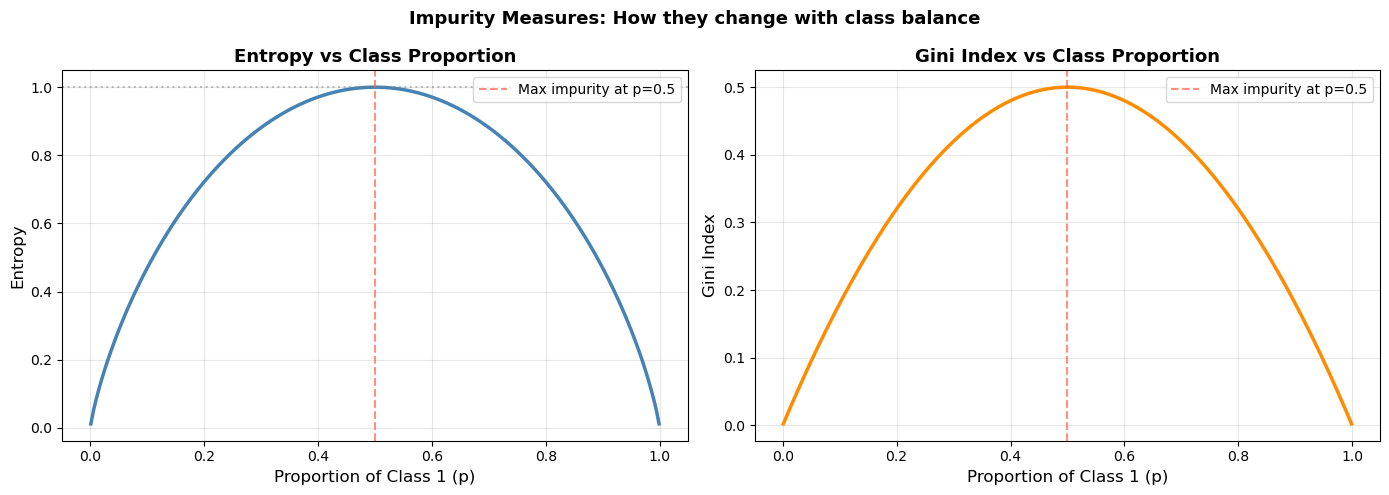

In [41]:
# Now we visualize how Entropy and Gini change as class proportion changes

proportions = np.linspace(0.001, 0.999, 200)
# Explanation: We are creating a range of 200 numbers between 0.001 and 0.999 using 'np.linspace'. This represents the 'proportion' (percentage) of a specific class in our data, from almost 0% to almost 100%.
# বাংলা ব্যাখ্যা: আমরা 'np.linspace' ব্যবহার করে ০.০০১ থেকে ০.৯৯৯ এর মধ্যে ২০০টি সংখ্যা তৈরি করছি। এটি আমাদের ডেটাতে কোনো একটি নির্দিষ্ট ক্লাসের 'proportion' বা শতকরা হার নির্দেশ করে (প্রায় ০% থেকে প্রায় ১০০% পর্যন্ত)।


entropy_values = [(-p * np.log2(p) - (1-p) * np.log2(1-p)) for p in proportions]
gini_values    = [(1 - p**2 - (1-p)**2) for p in proportions]
# Explanation: We are calculating the 'entropy_values' and 'gini_values' for every proportion we created. These formulas measure the "messiness" of the data at each point.
# বাংলা ব্যাখ্যা: আমরা প্রতিটি প্রপোরশনের জন্য 'entropy_values' এবং 'gini_values' ক্যালকুলেট করছি। এই সূত্রগুলো প্রতিটি পয়েন্টে ডেটা কতটা অগোছালো বা "জগাখিচুড়ি" অবস্থায় আছে তা পরিমাপ করে।


figure, axes = plt.subplots(1, 2, figsize=(14, 5))
# Explanation: We are setting up a side-by-side layout for our graphs using 'plt.subplots(1, 2)'. The 'figsize' ensures the charts are wide enough (14 inches) to see both curves clearly.
# বাংলা ব্যাখ্যা: আমরা 'plt.subplots(1, 2)' ব্যবহার করে পাশাপাশি দুটি গ্রাফ আঁকার জায়গা তৈরি করছি। 'figsize' নিশ্চিত করে যে চার্টগুলো যথেষ্ট চওড়া (১৪ ইঞ্চি) হবে যাতে দুটি কার্ভই পরিষ্কার দেখা যায়।


# Entropy curve
axes[0].plot(proportions, entropy_values, color="steelblue", linewidth=2.5)

axes[0].set_xlabel("Proportion of Class 1 (p)", fontsize=12)
axes[0].set_ylabel("Entropy", fontsize=12)
axes[0].set_title("Entropy vs Class Proportion", fontsize=13, fontweight="bold")

axes[0].axvline(0.5, color="tomato", linestyle="--", alpha=0.7, label="Max impurity at p=0.5")
axes[0].axhline(1.0, color="gray", linestyle=":", alpha=0.5)

axes[0].legend()
axes[0].grid(alpha=0.3)
# Explanation: We are plotting the 'Entropy' curve on the first chart. Notice the 'axvline' at 0.5; it highlights that Entropy is at its maximum (1.0) when the classes are perfectly split 50/50.
# বাংলা ব্যাখ্যা: আমরা প্রথম চার্টে 'Entropy' কার্ভটি আঁকছি। এখানে ০.৫ পয়েন্টে 'axvline' (উলম্ব রেখা) খেয়াল করো; এটি দেখাচ্ছে যে যখন ডেটা ৫০/৫০ অনুপাতে থাকে, তখন এনট্রপি সর্বোচ্চ (১.০) হয়।


# Gini curve
axes[1].plot(proportions, gini_values, color="darkorange", linewidth=2.5)

axes[1].set_xlabel("Proportion of Class 1 (p)", fontsize=12)
axes[1].set_ylabel("Gini Index", fontsize=12)

axes[1].set_title("Gini Index vs Class Proportion", fontsize=13, fontweight="bold")

axes[1].axvline(0.5, color="tomato", linestyle="--", alpha=0.7, label="Max impurity at p=0.5")

axes[1].legend()
axes[1].grid(alpha=0.3)
# Explanation: We are plotting the 'Gini Index' curve on the second chart. Like Entropy, it peaks at 0.5, but its maximum value is 0.5. We use 'set_xlabel' and 'set_ylabel' to label the axes for clarity.
# বাংলা ব্যাখ্যা: আমরা দ্বিতীয় চার্টে 'Gini Index' কার্ভটি আঁকছি। এনট্রপির মতোই এটি ০.৫ এ সর্বোচ্চ হয়, তবে এর সর্বোচ্চ মান হলো ০.৫। আমরা 'set_xlabel' এবং 'set_ylabel' ব্যবহার করে অক্ষগুলোর নাম দিচ্ছি যাতে বুঝতে সুবিধা হয়।


plt.suptitle("Impurity Measures: How they change with class balance",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# Explanation: Finally, we add a main title using 'suptitle' and use 'plt.show()' to display the plots. 'plt.tight_layout()' prevents the labels from overlapping.
# বাংলা ব্যাখ্যা: সবশেষে আমরা 'suptitle' দিয়ে একটি মূল শিরোনাম দিচ্ছি এবং 'plt.show()' দিয়ে গ্রাফগুলো দেখাচ্ছি। 'plt.tight_layout()' ব্যবহার করা হয়েছে যাতে একটির লেখা অন্যটির ওপর চলে না যায়।

> 📝 **এই code-এ কী হচ্ছে:** Entropy ও Gini-এর visual comparison। X-axis = Class 1-এর proportion (0 থেকে 1)। দুটোই p=0.5-এ maximum (most impure) এবং p=0 বা p=1-এ 0 (perfectly pure)।

> ### এই chart কীভাবে observe করব
> - X-axis = Class 1-এর proportion (0=সব Class 0, 1=সব Class 1)।
> - Y-axis = Impurity measure-এর value।
> - **P=0.5** (50-50 split) = maximum impurity — উভয় curve-এর peak।
> - **P=0 বা P=1** = minimum impurity (0) — one class dominates।

> ### এই chart থেকে কী observe করলাম
> - Entropy maximum = 1.0 (at p=0.5), Gini maximum = 0.5 (at p=0.5)।
> - দুটো curve-এর shape প্রায় same — একই information different scale-এ।
> - Split-এর লক্ষ্য: p=0.5 থেকে সরিয়ে p=0 বা p=1-এর দিকে নিয়ে যাওয়া।

> ### Decision
> Gini ও Entropy প্রায়ই same split বেছে নেয়। Gini computationally faster — sklearn default।


## গ্রাফগুলো থেকে ৩টি খুব গুরুত্বপূর্ণ **Observation** বা পর্যবেক্ষণ নেওয়া যায়:

### ১. ডেটার ভারসাম্য এবং কনফিউশন (Impurity)
গ্রাফে দেখা যাচ্ছে, যখন কোনো একটি ক্লাসের অনুপাত (Proportion) একদম **০.৫ (৫০%)** থাকে, তখন **Entropy** এবং **Gini Index** দুটির মানই সর্বোচ্চ থাকে।
* **পর্যবেক্ষণ:** এর মানে হলো, যখন ডেটাতে 'হ্যাঁ' এবং 'না' সমান সমান থাকে, তখন মডেলের জন্য সিদ্ধান্ত নেওয়া সবচেয়ে কঠিন হয় (সবচেয়ে বেশি কনফিউশন)।

### ২. পিউরিটি বা স্বচ্ছতা (Purity)
যখন অনুপাত **০** বা **১** এর দিকে যায়, তখন কার্ভগুলো নিচের দিকে নেমে আসে।
* **পর্যবেক্ষণ:** যখন গ্রুপে সবাই একই ধরণের হয় (সবাই 'Yes' অথবা সবাই 'No'), তখন এনট্রপি এবং গিনি **০ (Zero)** হয়ে যায়। ডিসিশন ট্রি সবসময় এমনভাবে ডেটা ভাগ করতে চায় যাতে সে এই ০ বা পিউরিটির কাছাকাছি পৌঁছাতে পারে।

### ৩. এনট্রপি বনাম গিনি (Entropy vs Gini Index)
দুটি গ্রাফের আকৃতি (Shape) প্রায় একই রকম হলেও একটি সূক্ষ্ম পার্থক্য আছে।
* **পর্যবেক্ষণ:** এনট্রপির সর্বোচ্চ মান হলো **১.০**, আর গিনির সর্বোচ্চ মান হলো **০.৫**। গিনি ইনডেক্স ক্যালকুলেট করা কম্পিউটারের জন্য সহজ এবং দ্রুত, তাই বড় ডেটাসেটে মডেল ডিফল্টভাবে গিনি ব্যবহার করে।

**সারকথা:** ডিসিশন ট্রি-র ছবিতে দেখো, টপ বক্সের (Root) গিনি ছিল **০.৫**, কারণ সেখানে ডেটা মিক্সড ছিল। কিন্তু নিচের বক্সগুলোতে (Leaves) গিনি **০.০** হয়ে গেছে। তোমার এই কার্ভ গ্রাফগুলোই প্রমাণ করছে যে, ভাগ করার ফলে কনফিউশন কমেছে এবং মডেল একটি পরিষ্কার সিদ্ধান্তে পৌঁছাতে পেরেছে।

---
## 11.4 Synthetic Data দিয়ে Decision Tree তৈরি

### sklearn-এ Decision Tree তৈরির steps
```python
from sklearn.tree import DecisionTreeClassifier

# Create model
tree = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)

# Train
tree.fit(X_train, y_train)

# Predict
y_pred = tree.predict(X_test)

# Feature importance
tree.feature_importances_  # array, sum=1.0
```

### Important Parameters

| Parameter | মানে | Default |
|---|---|---|
| `max_depth` | Tree-এর maximum depth | None (unlimited) |
| `criterion` | Impurity measure | 'gini' |
| `min_samples_split` | Split করতে minimum samples | 2 |
| `min_samples_leaf` | Leaf-এ minimum samples | 1 |
| `max_features` | Split-এ consider করার max features | None |

### 🎯 Interview Topics
- `max_depth=None` মানে? → Tree unlimited grow করে → overfitting guarantee
- `min_samples_leaf` কীভাবে overfitting রোধ করে? → Small leaf node তৈরি হতে দেয় না
- `feature_importances_` কী? → প্রতিটি feature কতটা Information Gain contribute করেছে
- `random_state` কেন দিই? → Tree training-এ tie-breaking random — reproducibility


In [42]:
# Now we create a larger synthetic dataset (module notebook exact code)
# make_classification creates a realistic binary classification dataset

X_synthetic_large, y_synthetic_large = make_classification(
    n_samples=400,       # Total data points
    n_features=5,        # Total feature number
    n_informative=3,     # Total relevant features
    n_redundant=0,       # No strong correlation among features
    n_classes=2,         # Target variable class number (binary)
    random_state=42      # Reproducible random dataset
)
# Explanation: We are using the 'make_classification' function to generate an artificial dataset. We specified 'n_samples=400' to get 400 rows and 'n_features=5' for 5 columns. 'n_informative=3' means only 3 of these columns actually help in predicting the target, while 'random_state=42' ensures we get the same data every time we run it.
# বাংলা ব্যাখ্যা: আমরা 'make_classification' ফাংশন ব্যবহার করে একটি কৃত্রিম বা ডামি ডেটাসেট তৈরি করছি। 'n_samples=400' দিয়ে আমরা ৪০০টি রো এবং 'n_features=5' দিয়ে ৫টি কলাম বা বৈশিষ্ট্য তৈরি করেছি। 'n_informative=3' এর মানে হলো এই ৫টি কলামের মধ্যে মাত্র ৩টি কলাম আসলে রেজাল্ট প্রেডিক্ট করতে সাহায্য করবে, আর 'random_state=42' ব্যবহার করা হয়েছে যাতে প্রতিবার কোডটি রান করলে আমরা একই ডেটা পাই।


# Here we convert to DataFrame for readability
feature_names = [f"Feature_{i+1}" for i in range(5)]
synthetic_dataframe = pd.DataFrame(X_synthetic_large, columns=feature_names)
synthetic_dataframe["Target"] = y_synthetic_large
# Explanation: The generated data is in a NumPy array, so we convert it into a 'pd.DataFrame' to make it look like a table. We name the columns from 'Feature_1' to 'Feature_5' and add a final column called 'Target' to store the labels (0 or 1).
# বাংলা ব্যাখ্যা: তৈরি হওয়া ডেটাগুলো নামপাই অ্যারে আকারে থাকে, তাই আমরা সেটিকে 'pd.DataFrame' এ রূপান্তর করছি যাতে এটি একটি টেবিলের মতো দেখায়। আমরা কলামগুলোর নাম 'Feature_1' থেকে 'Feature_5' দিচ্ছি এবং শেষে 'Target' নামে একটি কলাম যোগ করছি যেখানে আমাদের আসল ফলাফল বা লেবেলগুলো (০ অথবা ১) থাকবে।


print("Synthetic dataset shape:", synthetic_dataframe.shape)
print(f"Class distribution: 0={sum(y_synthetic_large==0)}, 1={sum(y_synthetic_large==1)}")
print()
print("First 5 rows:")
print(synthetic_dataframe.head())
# Explanation: We are printing the 'shape' to confirm there are 400 rows and 6 columns (5 features + 1 target). Then, we check the 'Class distribution' to see how many 0s and 1s we have, and finally, use '.head()' to show the first 5 rows of our new table.
# বাংলা ব্যাখ্যা: আমরা 'shape' প্রিন্ট করে নিশ্চিত হচ্ছি যে এখানে ৪০০টি রো এবং ৬টি কলাম (৫টি ফিচার + ১টি টার্গেট) আছে। এরপর আমরা 'Class distribution' চেক করছি দেখার জন্য যে আমাদের ডেটাতে কয়টি ০ এবং কয়টি ১ আছে, এবং সবশেষে '.head()' ব্যবহার করে টেবিলের প্রথম ৫টি রো দেখাচ্ছি।

Synthetic dataset shape: (400, 6)
Class distribution: 0=200, 1=200

First 5 rows:
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Target
0   3.326864   2.452265  -0.151273  -0.197338  -0.322585       1
1  -0.206180   1.386857  -0.290275   0.919076  -1.389236       0
2   0.910139   1.519274   0.424061  -0.809604   0.753308       1
3   0.535589   0.193379  -0.295480   0.560919   0.883607       1
4   1.319735   1.790492   2.057495   0.619154  -2.122222       1


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact `make_classification` code। `n_informative=3` মানে মাত্র ৩টি feature আসলে useful, বাকি ২টি noise। 400 samples, 5 features, 2 classes।

In [43]:
# Now we split and train the tree (module notebook exact code)

X_features = X_synthetic_large
y_target    = y_synthetic_large

X_train_large, X_test_large, y_train_large, y_test_large = train_test_split(
    X_features, y_target, test_size=0.3, random_state=42
)
# Explanation: We are splitting our large dataset into two parts using 'train_test_split'. 'test_size=0.3' means 30% of the data (120 rows) is kept aside for testing, and the remaining 70% (280 rows) will be used to train the model.
# বাংলা ব্যাখ্যা: আমরা 'train_test_split' ব্যবহার করে আমাদের বড় ডেটাসেটটিকে দুই ভাগে ভাগ করছি। 'test_size=0.3' দিয়ে বোঝানো হয়েছে যে ৩০% ডেটা (১২০টি রো) আমরা আলাদা রাখছি পরীক্ষার জন্য, আর বাকি ৭০% ডেটা (২৮০টি রো) দিয়ে মডেলটিকে শেখানো বা ট্রেইন করা হবে।


print(f"Training set: {X_train_large.shape}")
print(f"Test set:     {X_test_large.shape}")
# Explanation: We are printing the dimensions (shape) of our training and testing sets to confirm the split worked correctly. It shows how many samples are in 'X_train_large' versus 'X_test_large'.
# বাংলা ব্যাখ্যা: আমরা ট্রেইনিং এবং টেস্টিং সেটের আকার (shape) প্রিন্ট করছি এটা নিশ্চিত করতে যে ভাগটি ঠিকমতো হয়েছে কি না। এটি দেখাবে যে 'X_train_large' এবং 'X_test_large'-এ কয়টি করে স্যাম্পল আছে।


# Train a pruned tree (max_depth=4)
tree_synthetic = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_synthetic.fit(X_train_large, y_train_large)
# Explanation: We initialize the model using 'DecisionTreeClassifier'. We set 'max_depth=4' to prevent the tree from growing too long and becoming over-complicated (pruning). Then, we use '.fit()' to actually start the training process using our training data.
# বাংলা ব্যাখ্যা: আমরা 'DecisionTreeClassifier' দিয়ে মডেলটি শুরু করছি। এখানে 'max_depth=4' ব্যবহার করা হয়েছে যাতে গাছটি খুব বেশি বড় হয়ে জটিল না হয়ে যায় (একে প্রুনিং বলে)। এরপর '.fit()' ব্যবহার করে আমরা ট্রেইনিং ডেটা দিয়ে মডেলটিকে শেখানোর কাজ শুরু করছি।


print()
print("Tree trained!")
print(f"Tree depth: {tree_synthetic.get_depth()}")
print(f"Number of leaves: {tree_synthetic.get_n_leaves()}")
# Explanation: After training, we use '.get_depth()' to check how many levels the tree actually has and '.get_n_leaves()' to see the total number of final decision boxes (leaves) created by the model.
# বাংলা ব্যাখ্যা: ট্রেইনিং শেষ হওয়ার পর, আমরা '.get_depth()' দিয়ে দেখছি গাছটিতে কয়টি স্তর বা লেভেল তৈরি হয়েছে এবং '.get_n_leaves()' দিয়ে দেখছি মডেলটি মোট কতগুলো শেষ সিদ্ধান্ত বক্স (পাতা) তৈরি করেছে।

Training set: (280, 5)
Test set:     (120, 5)

Tree trained!
Tree depth: 4
Number of leaves: 10


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর train_test_split। 70% train, 30% test। `get_depth()` actual depth, `get_n_leaves()` leaf node সংখ্যা দেয়।

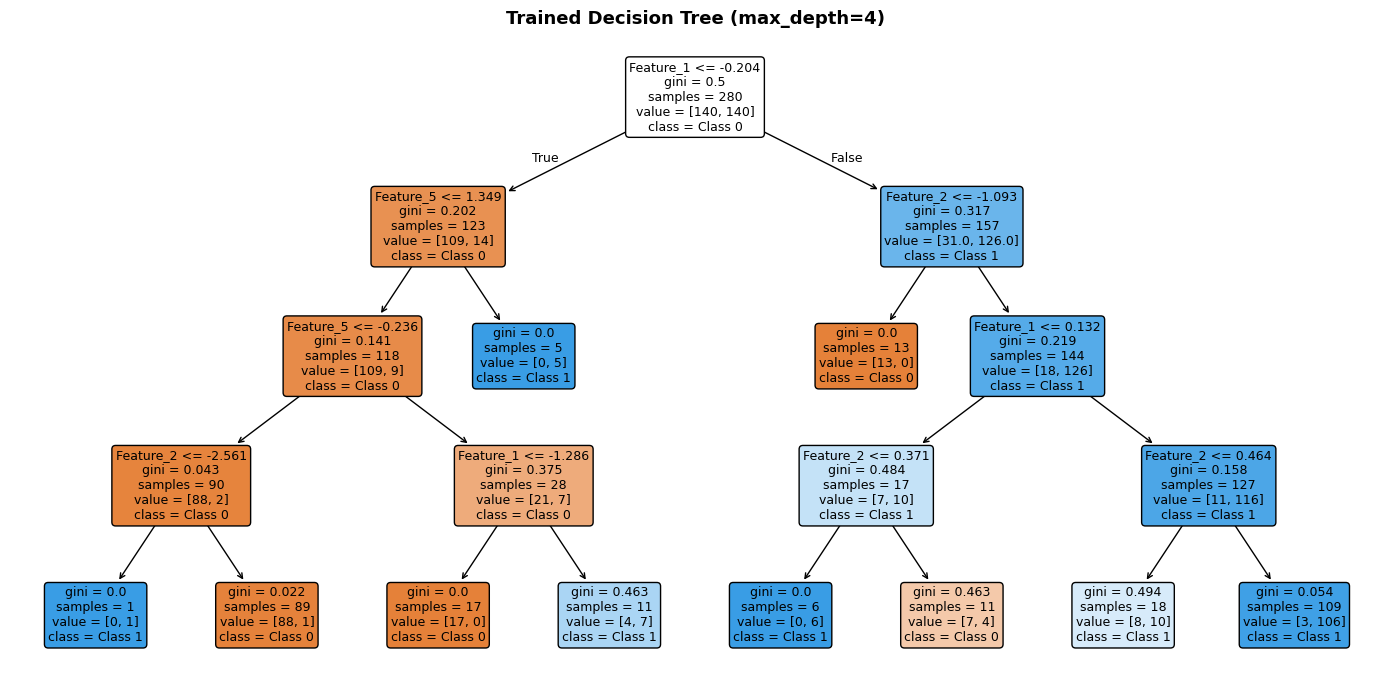

Feature Importances:
  Feature_1: 0.6543  ##########################
  Feature_2: 0.2538  ##########
  Feature_5: 0.0920  ###
  Feature_3: 0.0000  
  Feature_4: 0.0000  


In [12]:
# Now we visualize the trained tree

plt.figure(figsize=(14, 7))
plot_tree(
    tree_synthetic,
    feature_names=feature_names,
    class_names=["Class 0", "Class 1"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Trained Decision Tree (max_depth=4)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Here we show feature importance
print("Feature Importances:")
for feature_name, importance in sorted(
    zip(feature_names, tree_synthetic.feature_importances_),
    key=lambda x: x[1], reverse=True
):
    bar = "#" * int(importance * 40)
    print(f"  {feature_name}: {importance:.4f}  {bar}")

> 📝 **এই code-এ কী হচ্ছে:** Tree visualization এবং feature importance দেখানো হয়েছে। `feature_importances_` — প্রতিটি feature মোট Information Gain-এর কত % contribute করেছে (sum=1.0)। Bar chart visual দিয়ে relative importance বোঝা যায়।

> ### এই chart কীভাবে observe করব
> - **Root node** সবচেয়ে উপরে — সবচেয়ে important feature দিয়ে split।
> - প্রতিটি box-এ: condition | gini | samples | values=[class0_count, class1_count]।
> - **গাঢ় রঙ** = pure node, **হালকা** = mixed।
> - **Leaf node** (কোনো child নেই) = final prediction।

> ### এই chart থেকে কী observe করলাম
> - Root split Feature_1 বা Feature_2 দিয়ে — সবচেয়ে informative।
> - Depth বাড়ার সাথে গাঢ় রঙের node বাড়ে — tree শিখছে।
> - Feature Importance থেকে কোন feature বেশি কাজ করছে সেটা বোঝা যাচ্ছে।

> ### Decision
> এই tree max_depth=4 — reasonable। Deeper হলে overfitting ঝুঁকি।


---
## 11.5 Overfitting ও Pruning

### Overfitting কী? (PDF Slide থেকে)
> **Overfitting** = Tree training data memorize করে।
> Real pattern শেখার বদলে noise-ও মুখস্থ করে ফেলে।

```
Overfitting symptoms:
  Training accuracy:   99%   <- training data memorized!
  Test accuracy:       65%   <- fails on new data!
  Gap:                 34%   <- too large = overfitting
```

### কেন Decision Tree সহজে Overfit করে?
- `max_depth=None` দিলে leaf-এ single sample পর্যন্ত split করে
- প্রতিটি training sample-এর জন্য আলাদা path — memorization
- Noise এবং real pattern আলাদা করতে পারে না

### Pruning — Overfitting রোধের পদ্ধতি

| Parameter | কী করে | Effect |
|---|---|---|
| `max_depth` | Tree-এর maximum depth limit করে | সবচেয়ে common |
| `min_samples_split` | Split করতে minimum N sample লাগবে | Small group split বন্ধ |
| `min_samples_leaf` | Leaf-এ minimum N sample রাখে | Tiny leaf বন্ধ |
| `max_leaf_nodes` | Maximum leaf node count | Total complexity limit |
| `ccp_alpha` | Cost-complexity pruning | Post-pruning |

### 🎯 Interview Topics
- Pre-pruning vs Post-pruning? → Pre=growth সীমিত করা, Post=tree grow করার পরে branches কাটা
- `ccp_alpha` কী? → Complexity penalty। বাড়ালে tree ছোট হয়।
- High variance মানে? → Training data change হলে tree structure সম্পূর্ণ বদলায়
- Training-Test gap 5% এর কম → Good generalization


In [13]:
# Now we train deep tree vs pruned tree (module notebook exact code)

# Deep tree: no depth limit (overfitting expected)
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_large, y_train_large)

# Pruned tree: max_depth=3 (regularized)
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train_large, y_train_large)

# Predictions for both
y_train_pred_deep   = deep_tree.predict(X_train_large)
y_test_pred_deep    = deep_tree.predict(X_test_large)
y_train_pred_pruned = pruned_tree.predict(X_train_large)
y_test_pred_pruned  = pruned_tree.predict(X_test_large)

# Here we compare accuracies (module notebook exact output)
print("=" * 50)
print(f"{'Metric':<30} {'Deep':>10} {'Pruned':>10}")
print("-" * 50)
print(f"{'Train Accuracy':<30} {accuracy_score(y_train_large, y_train_pred_deep):>10.3f} {accuracy_score(y_train_large, y_train_pred_pruned):>10.3f}")
print(f"{'Test Accuracy':<30} {accuracy_score(y_test_large, y_test_pred_deep):>10.3f} {accuracy_score(y_test_large, y_test_pred_pruned):>10.3f}")
print(f"{'Tree Depth':<30} {deep_tree.get_depth():>10} {pruned_tree.get_depth():>10}")
print(f"{'Number of Leaves':<30} {deep_tree.get_n_leaves():>10} {pruned_tree.get_n_leaves():>10}")
gap_deep   = accuracy_score(y_train_large, y_train_pred_deep) - accuracy_score(y_test_large, y_test_pred_deep)
gap_pruned = accuracy_score(y_train_large, y_train_pred_pruned) - accuracy_score(y_test_large, y_test_pred_pruned)
print(f"{'Train-Test Gap':<30} {gap_deep:>10.3f} {gap_pruned:>10.3f}")
print("=" * 50)
print()
print("KEY INSIGHT: Deep tree has high train accuracy but big gap -> OVERFITTING")
print("Pruned tree has smaller gap -> Better GENERALIZATION")

Metric                               Deep     Pruned
--------------------------------------------------
Train Accuracy                      1.000      0.904
Test Accuracy                       0.883      0.892
Tree Depth                             10          3
Number of Leaves                       29          6
Train-Test Gap                      0.117      0.012

KEY INSIGHT: Deep tree has high train accuracy but big gap -> OVERFITTING
Pruned tree has smaller gap -> Better GENERALIZATION


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact deep vs pruned tree comparison। Deep tree training accuracy ≈ 100% কিন্তু test accuracy কম — overfitting। Pruned tree training accuracy কম কিন্তু train-test gap ছোট — better generalization।

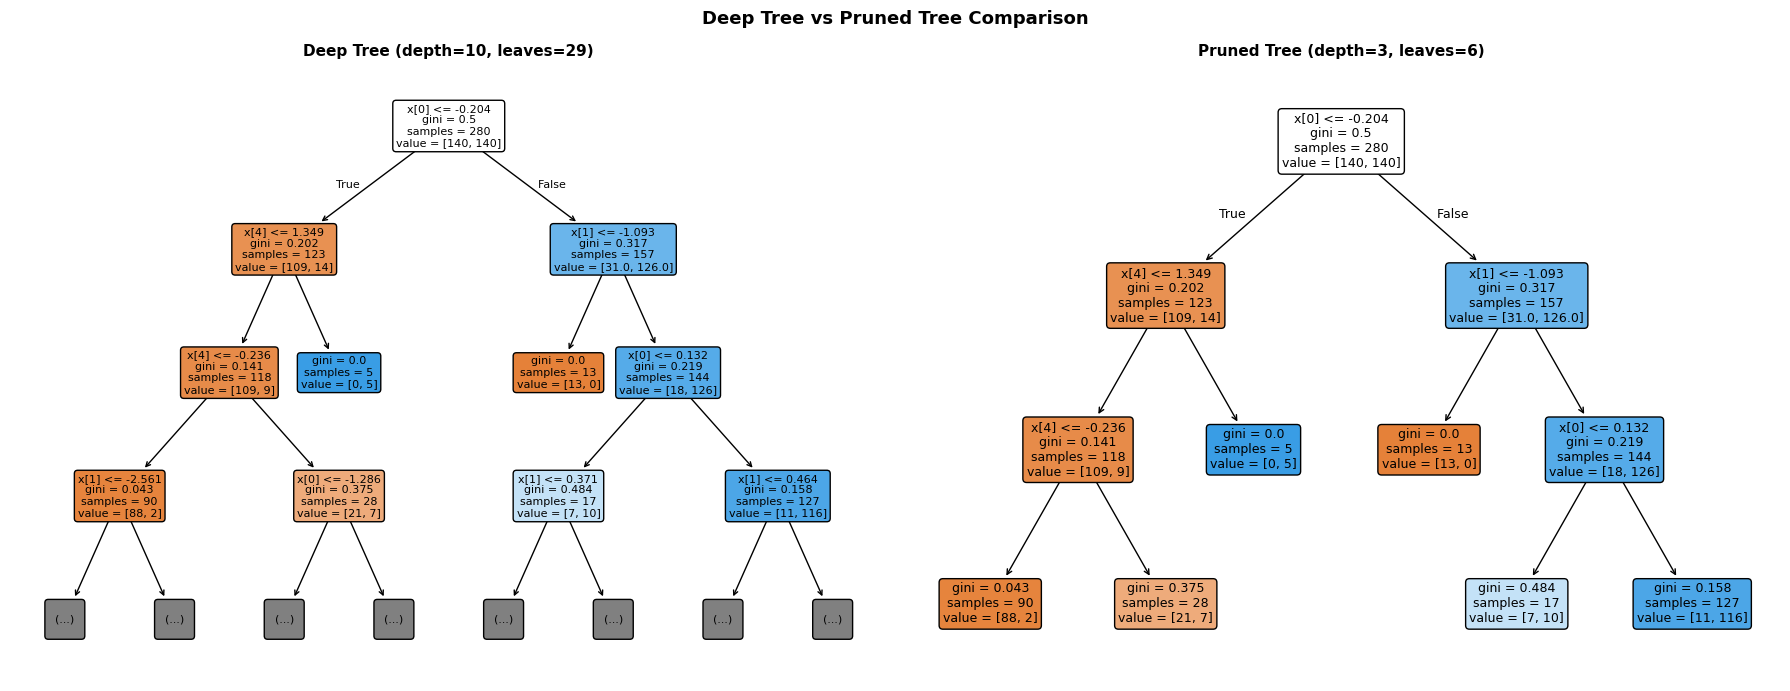

In [14]:
# Now we visualize both trees side by side (module notebook exact code)

figure, axes_array = plt.subplots(1, 2, figsize=(18, 7))

# Deep tree (showing only top levels for readability)
plot_tree(deep_tree, filled=True, rounded=True,
          max_depth=3, ax=axes_array[0], fontsize=8)
axes_array[0].set_title(f"Deep Tree (depth={deep_tree.get_depth()}, leaves={deep_tree.get_n_leaves()})",
                         fontsize=11, fontweight="bold")

# Pruned tree
plot_tree(pruned_tree, filled=True, rounded=True,
          ax=axes_array[1], fontsize=9)
axes_array[1].set_title(f"Pruned Tree (depth={pruned_tree.get_depth()}, leaves={pruned_tree.get_n_leaves()})",
                         fontsize=11, fontweight="bold")

plt.suptitle("Deep Tree vs Pruned Tree Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact two-tree visualization। Deep tree অনেক complex — অনেক node ও leaf। Pruned tree simple ও clean — interpretable।

> ### এই chart কীভাবে observe করব
> - **Left**: Deep tree — অনেক small node, অনেক branch।
> - **Right**: Pruned tree (depth=3) — simple, clean structure।

> ### এই chart থেকে কী observe করলাম
> - Deep tree অনেক complex — ছোট ছোট group তৈরি করে memorize করছে।
> - Pruned tree general pattern শিখেছে — interpretable।
> - Training accuracy-তে deep tree better, কিন্তু test-এ pruned comparable বা better।

> ### Decision
> Production-এ সবসময় pruned tree ব্যবহার করো। `max_depth` cross-validation দিয়ে tune করো।


Best depth by cross-validation: 2



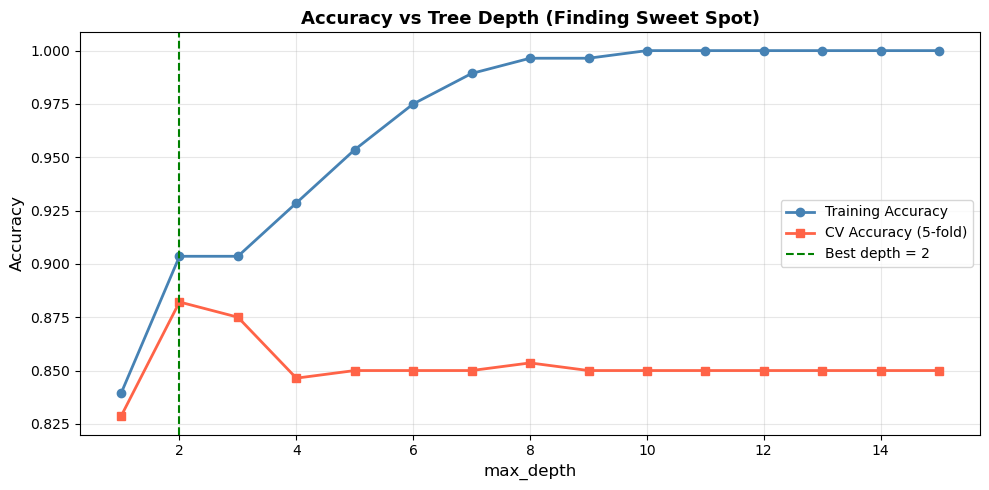

In [15]:
# BONUS: Find optimal max_depth using cross-validation

depth_values    = range(1, 16)
train_accuracies = []
cross_val_scores  = []

for depth in depth_values:
    tree_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_depth.fit(X_train_large, y_train_large)
    train_accuracies.append(accuracy_score(y_train_large, tree_depth.predict(X_train_large)))

    cv_score = cross_val_score(tree_depth, X_train_large, y_train_large, cv=5, scoring="accuracy")
    cross_val_scores.append(cv_score.mean())

# Find best depth
best_depth = depth_values[np.argmax(cross_val_scores)]
print(f"Best depth by cross-validation: {best_depth}")
print()

plt.figure(figsize=(10, 5))
plt.plot(depth_values, train_accuracies, marker="o", color="steelblue",
         linewidth=2, label="Training Accuracy")
plt.plot(depth_values, cross_val_scores, marker="s", color="tomato",
         linewidth=2, label="CV Accuracy (5-fold)")
plt.axvline(best_depth, color="green", linestyle="--",
            label=f"Best depth = {best_depth}")
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Tree Depth (Finding Sweet Spot)", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Cross-validation দিয়ে optimal depth খোঁজা হয়েছে। Training accuracy সবসময় বাড়ে — misleading। CV accuracy একটি point-এ peak করে তারপর কমে — এটাই optimal depth।

> ### এই chart কীভাবে observe করব
> - X-axis = max_depth value। Y-axis = Accuracy।
> - **Blue line** (Training): সবসময় বাড়তে থাকে।
> - **Red line** (CV): উপরে ওঠে তারপর নিচে নামে — sweet spot আছে।
> - **Green dashed line** = optimal depth যেখানে CV accuracy সর্বোচ্চ।

> ### এই chart থেকে কী observe করলাম
> - Training accuracy বেশি depth-এ 100% ছোঁয় — overfitting।
> - CV accuracy কোনো একটি depth-এ peak করে — এটাই best depth।
> - দুটো line-এর gap ছোট হওয়া ভালো।

> ### Decision
> Best depth = যেখানে CV accuracy সর্বোচ্চ। এই depth ব্যবহার করো।


---
## 11.6–11.7 Evaluation Metrics — Confusion Matrix, Precision, Recall, F1

### Confusion Matrix কী?
> একটি classification model-এর সব prediction একটি ২×২ table-এ দেখা।

```
                    PREDICTED
                  No Disease  |  Disease
ACTUAL  No Disease  [TN]     |  [FP]    <- False Alarm!
        Disease     [FN]     |  [TP]    <- Caught!
                    ^-- Missed!
```

| Cell | Full Name | মানে |
|---|---|---|
| **TN** | True Negative | Actually No, Predicted No ✓ |
| **FP** | False Positive | Actually No, Predicted Yes ✗ (False Alarm) |
| **FN** | False Negative | Actually Yes, Predicted No ✗ (**Most Dangerous**) |
| **TP** | True Positive | Actually Yes, Predicted Yes ✓ |

### চারটি Metric

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### কখন কোন Metric?

| Situation | Best Metric |
|---|---|
| Balanced classes | Accuracy |
| Imbalanced classes | F1 Score |
| FN costly (cancer, fraud) | **Recall** সর্বোচ্চ করো |
| FP costly (spam filter) | **Precision** সর্বোচ্চ করো |

### 🎯 Interview Topics
- Accuracy কখন misleading? → Imbalanced data-তে (99% class 0, 1% class 1 → সব 0 বললে 99% accuracy)
- Precision-Recall trade-off? → Threshold কমালে Recall বাড়ে, Precision কমে
- F1 কেন harmonic mean? → Arithmetic mean-এ একটি high হলে মাস্ক করে, harmonic mean balance করে
- Macro vs Micro vs Weighted average? → Macro=equal weight per class, Micro=sample count weight, Weighted=class proportion weight


In [16]:
# Now we create the heart-disease dataset (module notebook exact code)

np.random.seed(42)
number_of_samples = 300

patient_age       = np.random.randint(30, 80, size=number_of_samples)
patient_chol      = np.random.randint(150, 300, size=number_of_samples)
patient_thalach   = np.random.randint(90, 200, size=number_of_samples)

# Here we create a rule-based risk score (realistic but synthetic)
risk_score = 0.03 * (patient_age - 40) + 0.02 * (patient_chol - 200) - 0.02 * (patient_thalach - 140)
probability = 1 / (1 + np.exp(-0.05 * risk_score))
heart_disease_target = (probability > np.median(probability)).astype(int)

heart_dataframe = pd.DataFrame({
    "age":      patient_age,
    "chol":     patient_chol,
    "thalach":  patient_thalach,
    "target":   heart_disease_target
})

print("Heart disease dataset (synthetic, module notebook exact):")
print(heart_dataframe.head(10))
print()
print(f"Class distribution: No Disease={sum(heart_disease_target==0)}, Disease={sum(heart_disease_target==1)}")

Heart disease dataset (synthetic, module notebook exact):
   age  chol  thalach  target
0   68   253      128       1
1   58   233       90       1
2   44   261       92       1
3   72   248      166       1
4   37   242      181       0
5   50   295      151       1
6   68   277      152       1
7   48   259      114       1
8   52   231      145       0
9   40   203      122       0

Class distribution: No Disease=150, Disease=150


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact heart disease dataset। Age, cholesterol, max heart rate থেকে risk score calculate করে target তৈরি করা হয়েছে।

In [17]:
# Now we train-test split and train the tree (module notebook exact code)

X_heart_features = heart_dataframe[["age", "chol", "thalach"]]
y_heart_target    = heart_dataframe["target"]

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(
    X_heart_features, y_heart_target, test_size=0.2, random_state=42
)

# Train decision tree
heart_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
heart_tree.fit(X_train_heart, y_train_heart)

y_pred_heart = heart_tree.predict(X_test_heart)

print(f"Training set: {X_train_heart.shape}")
print(f"Test set:     {X_test_heart.shape}")
print("Model trained!")

Training set: (240, 3)
Test set:     (60, 3)
Model trained!


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact heart dataset split ও training।

In [18]:
# Now we compute confusion matrix (module notebook exact code)

confusion_matrix_values = confusion_matrix(y_test_heart, y_pred_heart)
print("Confusion Matrix:")
print(confusion_matrix_values)
print()

TN, FP, FN, TP = confusion_matrix_values.ravel()
print(f"True Negative  (TN): {TN}  -- correctly predicted No Disease")
print(f"False Positive (FP): {FP}  -- predicted Disease, actually No Disease (False Alarm)")
print(f"False Negative (FN): {FN}  -- predicted No Disease, actually DISEASE! (Dangerous!)")
print(f"True Positive  (TP): {TP}  -- correctly predicted Disease")

Confusion Matrix:
[[23  3]
 [ 6 28]]

True Negative  (TN): 23  -- correctly predicted No Disease
False Positive (FP): 3  -- predicted Disease, actually No Disease (False Alarm)
False Negative (FN): 6  -- predicted No Disease, actually DISEASE! (Dangerous!)
True Positive  (TP): 28  -- correctly predicted Disease


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact confusion matrix computation। `.ravel()` 2D matrix কে (TN, FP, FN, TP) flat array-এ convert করে। FN সবচেয়ে dangerous — sick patient miss হয়।

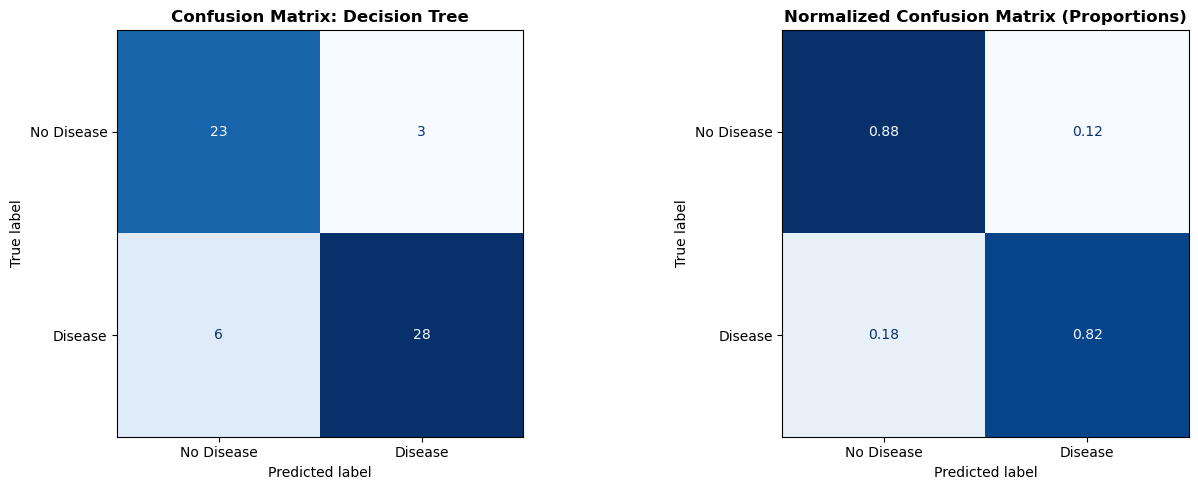

In [19]:
# Now we plot confusion matrix as heatmap (module notebook exact code with improvement)

figure, axes_array = plt.subplots(1, 2, figsize=(14, 5))

# Left: ConfusionMatrixDisplay (sklearn method)
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["No Disease", "Disease"]
)
confusion_matrix_display.plot(ax=axes_array[0], colorbar=False, cmap="Blues")
axes_array[0].set_title("Confusion Matrix: Decision Tree", fontsize=12, fontweight="bold")

# Right: Normalized confusion matrix (shows proportions)
confusion_matrix_normalized = confusion_matrix_values.astype("float") / confusion_matrix_values.sum(axis=1)[:, np.newaxis]
confusion_matrix_norm_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_normalized,
    display_labels=["No Disease", "Disease"]
)
confusion_matrix_norm_display.plot(ax=axes_array[1], colorbar=False, cmap="Blues",
                                    values_format=".2f")
axes_array[1].set_title("Normalized Confusion Matrix (Proportions)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Confusion matrix দুটো ভাবে দেখানো হয়েছে। Left = absolute counts। Right = normalized (row-wise proportion) — imbalanced class-এ more informative।

> ### এই chart কীভাবে observe করব
> - **Top-left (TN)**: Correctly predicted No Disease।
> - **Top-right (FP)**: False Alarm — healthy patient-কে sick বলা।
> - **Bottom-left (FN)**: **Missed disease** — sick patient-কে healthy বলা → most dangerous!
> - **Bottom-right (TP)**: Correctly caught disease.
> - Normalized-এ diagonal-এ 1.0 = perfect model।

> ### এই chart থেকে কী observe করলাম
> - FN কত? → মিস হওয়া disease patient count।
> - FP কত? → Unnecessary alarm count।
> - Diagonal sum বেশি = model ভালো।

> ### Decision
> Medical context-এ FN কম করাই priority — Recall maximize করো।


In [20]:
# Now we compute all classification metrics (module notebook exact code)

accuracy  = accuracy_score(y_test_heart, y_pred_heart)
precision = precision_score(y_test_heart, y_pred_heart)
recall    = recall_score(y_test_heart, y_pred_heart)
f1        = f1_score(y_test_heart, y_pred_heart)

print("Classification Metrics:")
print(f"  Accuracy:  {accuracy:.4f}  -- overall correct predictions")
print(f"  Precision: {precision:.4f}  -- of predicted disease, how many truly have it")
print(f"  Recall:    {recall:.4f}  -- of actual disease, how many were caught")
print(f"  F1 Score:  {f1:.4f}  -- harmonic mean of precision and recall")
print()
print("Full Classification Report:")
print(classification_report(y_test_heart, y_pred_heart,
                             target_names=["No Disease", "Disease"]))

Classification Metrics:
  Accuracy:  0.8500  -- overall correct predictions
  Precision: 0.9032  -- of predicted disease, how many truly have it
  Recall:    0.8235  -- of actual disease, how many were caught
  F1 Score:  0.8615  -- harmonic mean of precision and recall

Full Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.88      0.84        26
     Disease       0.90      0.82      0.86        34

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact metrics code। Classification report-এ দুটো class-এর আলাদা precision, recall, F1 দেখা যায়। Support = সেই class-এ test sample count।

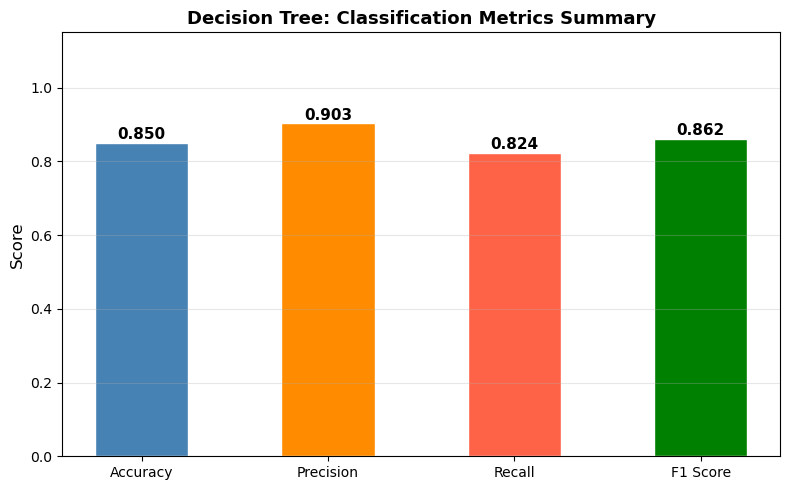

In [21]:
# Now we visualize all metrics as a bar chart

metric_names  = ["Accuracy", "Precision", "Recall", "F1 Score"]
metric_values = [accuracy, precision, recall, f1]
metric_colors = ["steelblue", "darkorange", "tomato", "green"]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=metric_colors, edgecolor="white", width=0.5)
for bar_item, value in zip(bars, metric_values):
    plt.text(bar_item.get_x() + bar_item.get_width()/2,
             bar_item.get_height() + 0.01,
             f"{value:.3f}", ha="center", fontsize=11, fontweight="bold")
plt.ylim(0, 1.15)
plt.ylabel("Score", fontsize=12)
plt.title("Decision Tree: Classification Metrics Summary", fontsize=13, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** সব metrics একসাথে bar chart-এ দেখানো হয়েছে — quick comparison।

> ### এই chart কীভাবে observe করব
> - প্রতিটি bar একটি metric। সর্বোচ্চ = 1.0 (perfect)।
> - সব bar-ই কাছাকাছি থাকলে model balanced।
> - Recall বেশি কম হলে → অনেক disease miss হচ্ছে।

> ### Decision
> Medical context-এ Recall বাড়ানো priority। Threshold কমিয়ে Recall increase করা যায়।


---
## 11.8–11.9 ROC Curve, AUC, এবং Threshold Interpretation

### Classification Threshold কী? (PDF Slide থেকে)
> Model probability দেয় — 0 থেকে 1।
> Threshold = সেই cutoff যেখানে probability-কে class-এ convert করা হয়।

```
Default threshold = 0.5:
  probability >= 0.5  ->  Class 1 (Disease)
  probability < 0.5   ->  Class 0 (No Disease)
```

**Threshold পরিবর্তনের effect:**
| Threshold | Effect |
|---|---|
| **Low (0.3)** | বেশি positive predict → Recall ↑, Precision ↓ |
| **Default (0.5)** | Balanced |
| **High (0.7+)** | কম positive predict → Precision ↑, Recall ↓ |

### ROC Curve কী?
> **ROC** = Receiver Operating Characteristic
> সব possible threshold-এ TPR vs FPR plot করা।

$$TPR (Recall) = \frac{TP}{TP + FN}$$

$$FPR = \frac{FP}{FP + TN}$$

### ROC Curve Shape-এর অর্থ (PDF Slide থেকে)
| Curve | মানে |
|---|---|
| **Top-left corner-এর কাছে** | Good model — high TPR, low FPR |
| **Diagonal line** | Random model (coin flip) — AUC = 0.5 |
| **Below diagonal** | Broken model — predictions inverted |

### AUC (Area Under the Curve)
> ROC curve-এর নিচের total area = AUC

| AUC Value | মানে |
|---|---|
| **1.0** | Perfect model |
| **0.9+** | Excellent |
| **0.7-0.9** | Good |
| **0.5-0.7** | Fair — marginal |
| **0.5** | Random — useless |
| **< 0.5** | Worse than random |

### 🎯 Interview Topics
- ROC-AUC vs Accuracy কখন কোনটা? → Imbalanced class-এ ROC-AUC বেশি informative
- AUC-এর probabilistic interpretation? → Randomly picked positive sample > randomly picked negative sample-এর probability
- Threshold কীভাবে বেছে নেব? → ROC curve দেখে, business requirement অনুযায়ী
- AUPRC (Precision-Recall Curve)? → Highly imbalanced class-এ ROC-AUC misleading হতে পারে, AUPRC better


In [22]:
# Now we compute predicted probabilities (module notebook exact code)

# predict_proba() returns probabilities for each class
# [:, 1] takes the probability of Class 1 (Disease)
y_probability_heart = heart_tree.predict_proba(X_test_heart)[:, 1]

print("First 10 predicted probabilities (for Class 1 = Disease):")
print(y_probability_heart[:10].round(3))
print()
print("These are NOT 0 or 1 -- they are the model's CONFIDENCE that class = 1")
print(f"Min probability: {y_probability_heart.min():.3f}")
print(f"Max probability: {y_probability_heart.max():.3f}")

First 10 predicted probabilities (for Class 1 = Disease):
[0.875 0.    0.048 0.    0.875 1.    1.    1.    1.    0.   ]

These are NOT 0 or 1 -- they are the model's CONFIDENCE that class = 1
Min probability: 0.000
Max probability: 1.000


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact `predict_proba()` code। `predict_proba()` প্রতিটি class-এর probability দেয়। `[:, 1]` দিয়ে Disease class-এর probability নেওয়া হয়েছে।

In [23]:
# Now we compute ROC curve and AUC (module notebook exact code)

false_positive_rates, true_positive_rates, thresholds = roc_curve(
    y_test_heart, y_probability_heart
)
roc_auc_value = auc(false_positive_rates, true_positive_rates)

print(f"AUC: {roc_auc_value:.4f}")
print()
print(f"This means: model correctly ranks a sick patient above a healthy one")
print(f"{roc_auc_value*100:.1f}% of the time!")

AUC: 0.9253

This means: model correctly ranks a sick patient above a healthy one
92.5% of the time!


> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact ROC ও AUC computation。 `roc_curve()` সব threshold-এ FPR ও TPR দেয়। `auc()` curve-এর নিচের area calculate করে।

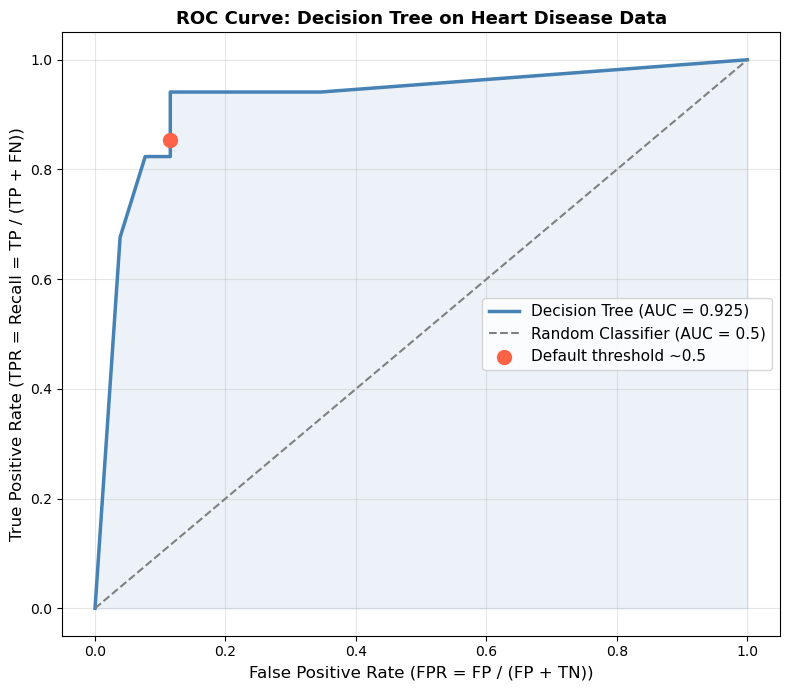

In [24]:
# Now we plot the ROC curve (module notebook exact code + improvement)

plt.figure(figsize=(8, 7))
plt.plot(
    false_positive_rates, true_positive_rates,
    color="steelblue", linewidth=2.5,
    label=f"Decision Tree (AUC = {roc_auc_value:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="Random Classifier (AUC = 0.5)")
plt.fill_between(false_positive_rates, true_positive_rates, alpha=0.1, color="steelblue")

# Mark the default threshold point (threshold ~= 0.5)
plt.scatter([false_positive_rates[len(thresholds)//2]],
            [true_positive_rates[len(thresholds)//2]],
            color="tomato", s=100, zorder=5, label="Default threshold ~0.5")

plt.xlabel("False Positive Rate (FPR = FP / (FP + TN))", fontsize=12)
plt.ylabel("True Positive Rate (TPR = Recall = TP / (TP + FN))", fontsize=12)
plt.title("ROC Curve: Decision Tree on Heart Disease Data", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Module notebook-এর exact ROC curve plot। Blue curve = model। Gray dashed = random (baseline)। Blue fill = AUC area। Red dot = default threshold point।

> ### এই chart কীভাবে observe করব
> - X-axis = FPR (False Positive Rate, 0-1)।
> - Y-axis = TPR = Recall (True Positive Rate, 0-1)।
> - **Blue curve যত উপরে-বামে** = model তত ভালো।
> - **Gray diagonal** = random classifier (AUC=0.5)।
> - **AUC** = blue area। 1.0=perfect, 0.5=random।
> - প্রতিটি point = একটি specific threshold।

> ### এই chart থেকে কী observe করলাম
> - Curve diagonal-এর উপরে — model random-এর চেয়ে ভালো।
> - AUC value দেখো — 0.7+ হলে model useful।
> - Top-left corner-এ একটি point আছে — ideal threshold সেখানে।

> ### Decision
> Medical context-এ: threshold কমাও → TPR বাড়ে (কম disease miss হয়), কিন্তু FPR-ও বাড়ে।


In [25]:
# Now we show the effect of different thresholds (PDF slide concept)

print("Effect of Changing Decision Threshold:")
print()
print(f"{'Threshold':>12} {'Accuracy':>10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 58)

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred_threshold = (y_probability_heart >= threshold).astype(int)
    acc   = accuracy_score(y_test_heart, y_pred_threshold)
    prec  = precision_score(y_test_heart, y_pred_threshold, zero_division=0)
    rec   = recall_score(y_test_heart, y_pred_threshold, zero_division=0)
    f1_val = f1_score(y_test_heart, y_pred_threshold, zero_division=0)
    print(f"{threshold:>12.1f} {acc:>10.4f} {prec:>12.4f} {rec:>10.4f} {f1_val:>10.4f}")

print()
print("OBSERVE:")
print("  Lower threshold -> Recall increases, Precision decreases")
print("  Higher threshold -> Precision increases, Recall decreases")
print("  Medical: prefer lower threshold (catch more disease, some false alarms OK)")

Effect of Changing Decision Threshold:

   Threshold   Accuracy    Precision     Recall         F1
----------------------------------------------------------
         0.2     0.8500       0.9032     0.8235     0.8615
         0.3     0.8500       0.9032     0.8235     0.8615
         0.4     0.8500       0.9032     0.8235     0.8615
         0.5     0.8500       0.9032     0.8235     0.8615
         0.6     0.8500       0.9032     0.8235     0.8615
         0.7     0.8500       0.9032     0.8235     0.8615
         0.8     0.8500       0.9032     0.8235     0.8615

OBSERVE:
  Lower threshold -> Recall increases, Precision decreases
  Higher threshold -> Precision increases, Recall decreases
  Medical: prefer lower threshold (catch more disease, some false alarms OK)


> 📝 **এই code-এ কী হচ্ছে:** PDF slide-এর threshold tuning concept code-এ দেখানো হয়েছে। Threshold কমালে Recall বাড়ে (কম disease miss) কিন্তু Precision কমে (বেশি false alarm)। Business context অনুযায়ী threshold বেছে নিতে হবে।

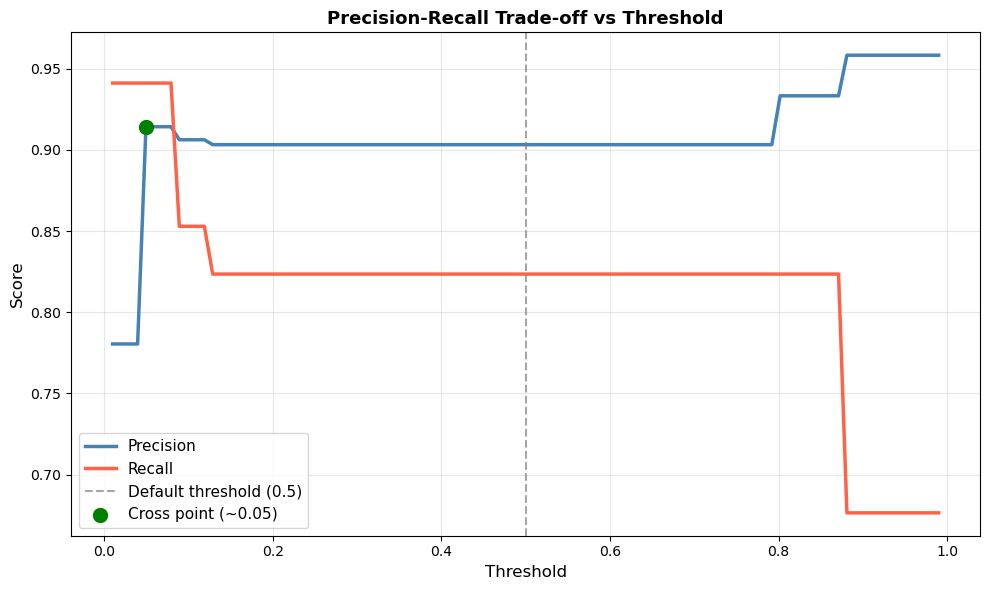

In [26]:
# Now we visualize Precision-Recall tradeoff as threshold changes

threshold_values     = np.linspace(0.01, 0.99, 100)
precision_at_threshold = []
recall_at_threshold    = []

for threshold in threshold_values:
    y_pred_t = (y_probability_heart >= threshold).astype(int)
    if sum(y_pred_t) == 0:
        precision_at_threshold.append(1.0)
        recall_at_threshold.append(0.0)
    else:
        precision_at_threshold.append(precision_score(y_test_heart, y_pred_t, zero_division=1))
        recall_at_threshold.append(recall_score(y_test_heart, y_pred_t, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(threshold_values, precision_at_threshold, color="steelblue", linewidth=2.5, label="Precision")
plt.plot(threshold_values, recall_at_threshold,    color="tomato",    linewidth=2.5, label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.7, label="Default threshold (0.5)")

# Mark where precision and recall cross
cross_idx = np.argmin(np.abs(np.array(precision_at_threshold) - np.array(recall_at_threshold)))
plt.scatter([threshold_values[cross_idx]],
            [precision_at_threshold[cross_idx]],
            color="green", s=100, zorder=5, label=f"Cross point (~{threshold_values[cross_idx]:.2f})")

plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Precision-Recall Trade-off vs Threshold", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> 📝 **এই code-এ কী হচ্ছে:** Precision-Recall trade-off visualization — threshold পরিবর্তনের effect। Blue line (Precision) থ্রেশহোল্ড বাড়ার সাথে বাড়ে। Red line (Recall) থ্রেশহোল্ড বাড়ার সাথে কমে। Cross point = balanced threshold।

> ### এই chart কীভাবে observe করব
> - X-axis = threshold (0 থেকে 1)। Y-axis = metric score।
> - **Blue (Precision)**: threshold বাড়লে বাড়ে।
> - **Red (Recall)**: threshold বাড়লে কমে।
> - **Green dot** = দুটো line cross করার point — balanced threshold।

> ### এই chart থেকে কী observe করলাম
> - Default 0.5-এ Precision ও Recall-এর exact value দেখা যায়।
> - Medical: Recall বেশি গুরুত্বপূর্ণ → threshold কমাও (0.3-0.4 range)।
> - Spam filter: Precision বেশি গুরুত্বপূর্ণ → threshold বাড়াও (0.6-0.7 range)।

> ### Decision
> Business requirement অনুযায়ী threshold বেছে নাও। কখনো blindly 0.5 নয়।


---
## 11.10 Conclusion — Module 11 Complete Summary

### সব Topics একনজরে (PDF Slide থেকে)

| Topic | মূল কথা |
|---|---|
| **Decision Tree** | If-else rules-এর chain। Recursive data splitting। |
| **Root Node** | সবচেয়ে important feature দিয়ে প্রথম split। |
| **Leaf Node** | Final prediction — majority class। |
| **Entropy** | Disorder measure। Range 0-1। 0=pure, 1=maximum impure। |
| **Gini Index** | Misclassification probability। Range 0-0.5। sklearn default। |
| **Information Gain** | Parent impurity - weighted child impurity। Maximize করা হয়। |
| **Overfitting** | Training accuracy >> Test accuracy। Tree memorizes noise। |
| **Pruning** | max_depth, min_samples_leaf দিয়ে complexity limit করা। |
| **Confusion Matrix** | TN, FP, FN, TP — সব prediction breakdown। |
| **Precision** | Predicted positive-এর মধ্যে actually positive কত। |
| **Recall** | Actual positive-এর মধ্যে কত ধরা গেছে। Medical-এ critical। |
| **F1 Score** | Precision ও Recall-এর harmonic mean। Imbalanced-এ best। |
| **ROC Curve** | সব threshold-এ TPR vs FPR plot। |
| **AUC** | ROC curve-এর area। 1=perfect, 0.5=random। |
| **Threshold** | Default 0.5। Business context অনুযায়ী adjust করো। |

### Interview Quick Reference
```
Q: Entropy vs Gini?
A: Both measure impurity. Entropy uses log, Gini uses probability squared.
   sklearn default = Gini (faster). Same result usually.

Q: Decision Tree-এর সবচেয়ে বড় weakness?
A: Overfitting (high variance). Small data change -> completely different tree.

Q: max_depth কীভাবে set করবে?
A: Cross-validation দিয়ে। range(1,15) try করে CV accuracy সর্বোচ্চ যেখানে।

Q: Medical context-এ কোন metric বেশি important?
A: RECALL. FN (missed disease) = most dangerous. Lower threshold to maximize recall.

Q: AUC = 0.5 মানে কী?
A: Model random guess-এর চেয়ে ভালো না। Worse than coin flip!

Q: Feature Importance কীভাবে বের করো?
A: tree.feature_importances_ -- আলাদা sum=1.0 হয়। Root feature সবচেয়ে বেশি।

Q: Decision Tree scale করতে হয় কেন না?
A: Split শুধু ordering দেখে, actual value নয়. Age=30 vs 50 -> just 30<50.

Q: Random Forest কীভাবে Decision Tree-এর উপর বেস?
A: অনেক trees তৈরি করে majority vote নেয়. Individual tree unstable হলেও
   ensemble stable হয় (variance কমে).
```

### Next Module Preview
> **Ensemble Methods (Random Forest, XGBoost)**
> - Random Forest: অনেক Decision Tree-এর majority vote
> - Gradient Boosting: Sequential trees, প্রতিটি আগেরটার error correct করে
> - এগুলো Decision Tree-এর সব weakness সমাধান করে


In [27]:
# FINAL REVIEW: Complete Decision Tree Pipeline

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

print("=" * 60)
print("MODULE 11: COMPLETE DECISION TREE PIPELINE")
print("=" * 60)

# Step 1: Use our heart disease dataset
X_final = heart_dataframe[["age", "chol", "thalach"]]
y_final  = heart_dataframe["target"]

# Step 2: Split
X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Step 3: Find best depth with cross-validation
best_depth_final   = None
best_cv_score = 0
for depth in range(1, 10):
    tree_cv = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_mean = cross_val_score(tree_cv, X_tr, y_tr, cv=5).mean()
    if cv_mean > best_cv_score:
        best_cv_score = cv_mean
        best_depth_final   = depth

print(f"\nBest depth (CV): {best_depth_final}, CV Accuracy: {best_cv_score:.4f}")

# Step 4: Train final model
final_tree = DecisionTreeClassifier(max_depth=best_depth_final, random_state=42)
final_tree.fit(X_tr, y_tr)

# Step 5: Evaluate
y_pred_final = final_tree.predict(X_te)
y_prob_final = final_tree.predict_proba(X_te)[:, 1]

print(f"\nFINAL RESULTS:")
print(f"  Accuracy:  {accuracy_score(y_te, y_pred_final):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_te, y_prob_final):.4f}")
print()

TN_f, FP_f, FN_f, TP_f = confusion_matrix(y_te, y_pred_final).ravel()
print(f"  True Positives (TP):  {TP_f}  (Disease correctly caught)")
print(f"  False Negatives (FN): {FN_f}  (Disease MISSED -- minimize this!)")
print()
print(classification_report(y_te, y_pred_final, target_names=["No Disease", "Disease"]))
print("Module 11 Complete!")

MODULE 11: COMPLETE DECISION TREE PIPELINE

Best depth (CV): 4, CV Accuracy: 0.8958

FINAL RESULTS:
  Accuracy:  0.8500
  ROC-AUC:   0.9253

  True Positives (TP):  28  (Disease correctly caught)
  False Negatives (FN): 6  (Disease MISSED -- minimize this!)

              precision    recall  f1-score   support

  No Disease       0.79      0.88      0.84        26
     Disease       0.90      0.82      0.86        34

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60

Module 11 Complete!


> 📝 **এই code-এ কী হচ্ছে:** Module 11-এর complete pipeline — CV দিয়ে best depth খোঁজা, train, evaluate। FN highlight করা হয়েছে — medical context-এ এটাই সবচেয়ে important metric।

---